# HPB Hackathon 2026 — AI Sustav za Predviđanje Odlaska Klijenata

  HPB HACKATHON — Churn Prevention System

[1/9] Učitavanje podataka...
  ✓ Klijenti:          11,997
  ✓ Proizvodi:         58,703
  ✓ Stanja:           817,933
  ✓ Transakcije:     1,187,661
  ✓ Kontakt centar:    23,605

[2/9] Parsiranje tipova i datuma...
  ✓ Referentni datum: 2026-04-14
  ✓ Joinovi postavljeni

[3/9] Računanje CLV Score...
  ✓ CLV Score — prosjek: 23.0  medijan: 12.1

[4/9] Računanje Churn Risk Score...
  ✓ Churn Risk Score — prosjek: 17.9  medijan: 20.0
  ✓ Klijenata s kreditom (binding cap): 429 (3.6%)

[5/9] Računanje Future Potential Score...
  ✓ Future Potential Score — prosjek: 32.0  medijan: 31.0
  ✓ Job score distribucija:
      25 bod —    41 klijenata
      22 bod —    75 klijenata
      18 bod —   608 klijenata
      14 bod —  1194 klijenata
      12 bod —   232 klijenata
      10 bod —  8821 klijenata
       8 bod —   116 klijenata
       7 bod —    37 klijenata
       4 bod —   873 klijenata

[7/9] Izračun Priority Score i segmentacija...

  SEGMENT  

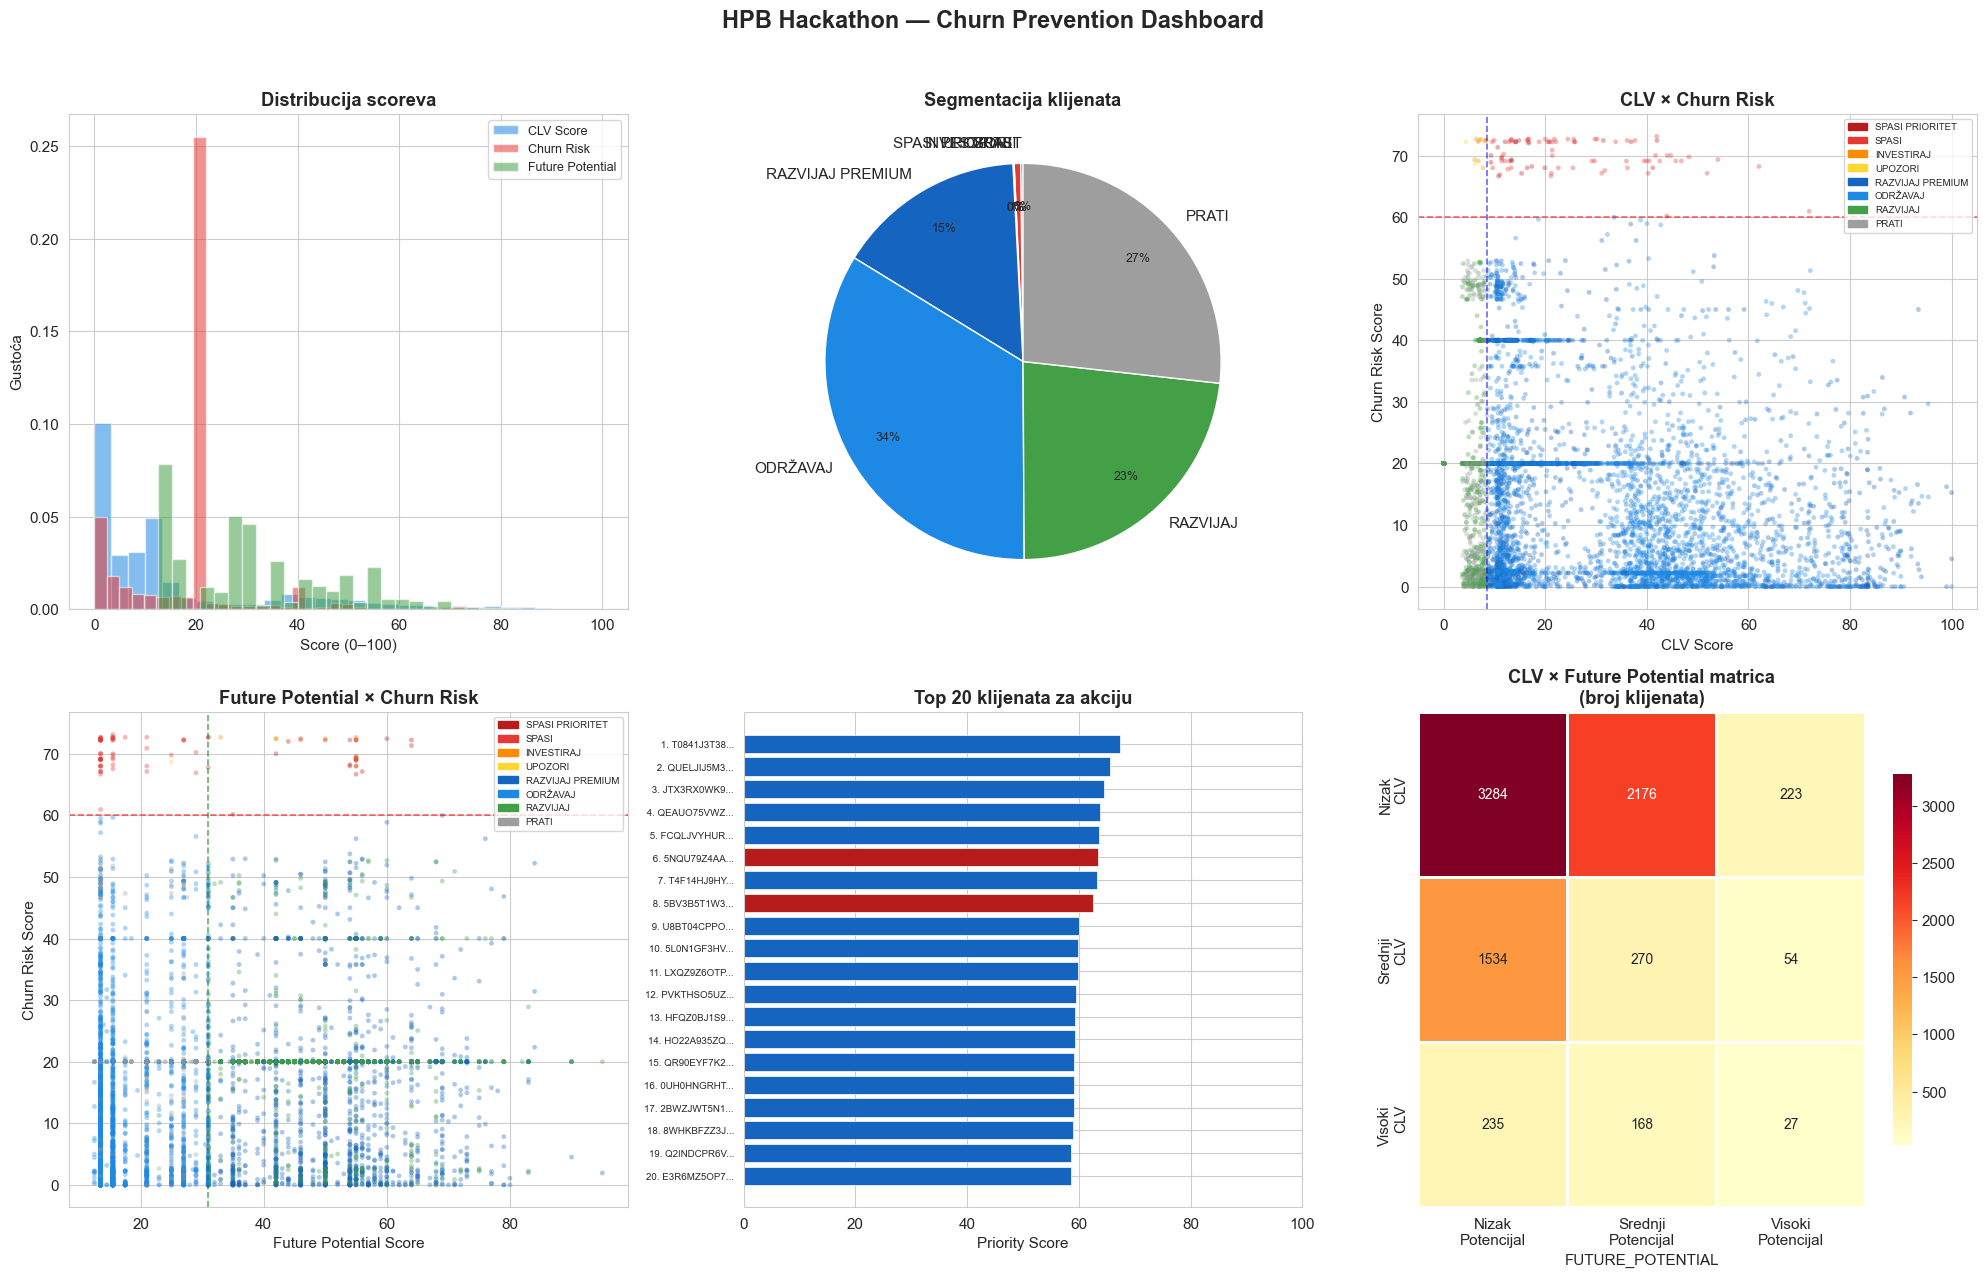

  ✓ Dashboard: churn_dashboard.png

[9/9] Priča jednog klijenta — Demo
──────────────────────────────────────────────────────────────

👤  Klijent:           3L0UXCNPSJPW
    Dob:               63 godina
    Zaposlenje:        UMIROVLJENIK
    Tenure:            5.8 godina u HPB-u
    Prima plaću u HPB: DA
    Aktivnih proizvoda:15
    Ima kredit:        NE

📊  SCOREVI:
    CLV Score:           72.0 / 100
    Churn Risk:          61.0 / 100  ⚠️
    Future Potential:    13.5 / 100
    ────────────────────────────
    PRIORITY SCORE:      57.9 / 100

🎯  SEGMENT:  SPASI
💡  AKCIJA:   📞  Potrebna intervencija bankara


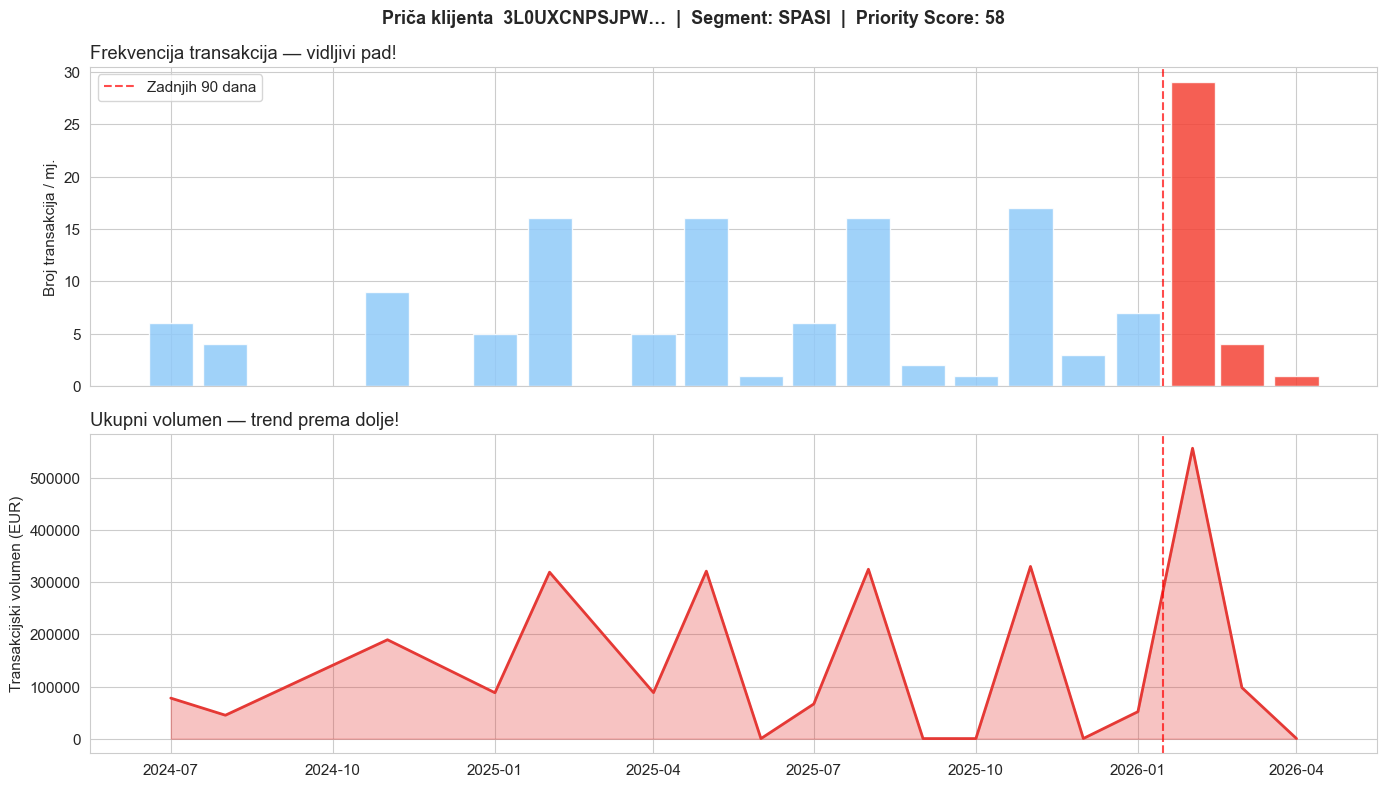


  ✓ Client story: client_story.png

  ✓ Rezultati: churn_results.csv  (11,997 klijenata)

  ZAVRŠENO!


══════════════════════════════════════════════════════════════════════
  ANALIZA POTROŠNJE — kategorije i partner mapa
══════════════════════════════════════════════════════════════════════
  Klijenata s partner ponudom:  36
  Ukupno partner preporuka:     36

  Top partner kategorije:
PARTNER_TIP
Zdravlje       32
Obrazovanje     4


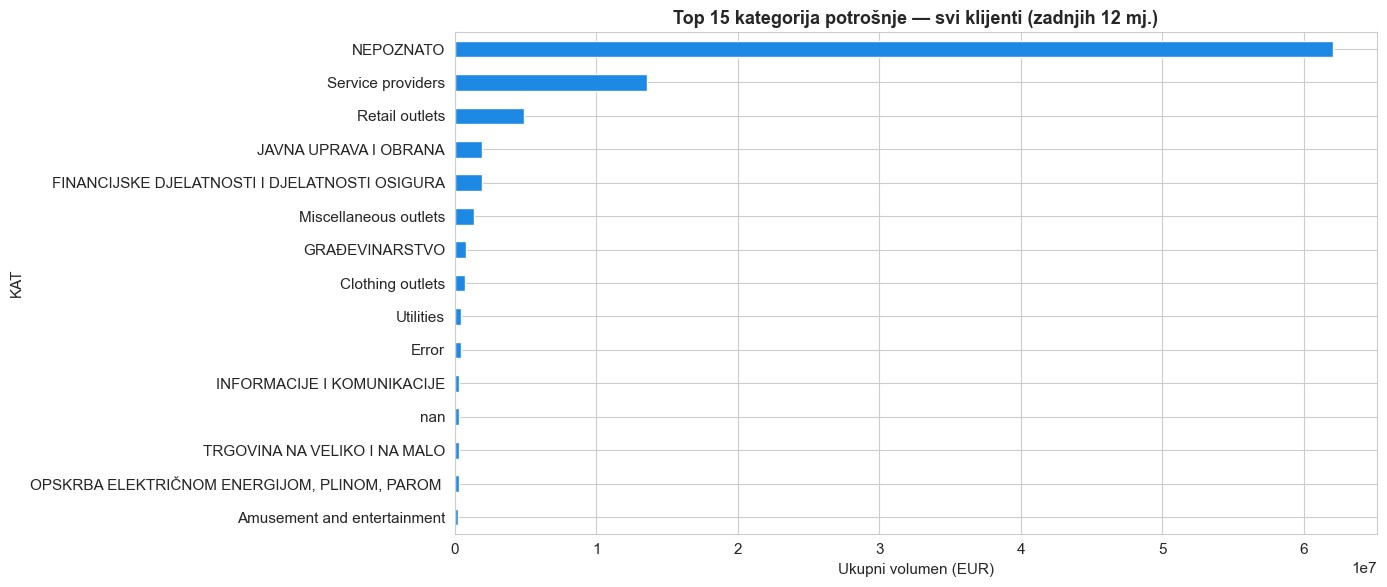



══════════════════════════════════════════════════════════════════════
  NEXT BEST OFFER ENGINE — Personalne ponude za bankara
══════════════════════════════════════════════════════════════════════

  Klijenata s barem 1 bankarskim proizvodom: 8,811 / 11,997
  Klijenata s barem 1 partner ponudom:     4,855 / 11,997
  Prosječan broj bankarskih ponuda: 0.8
  Prosječan broj partner ponuda:    0.8

  Distribucija bankarskih proizvoda (bankar odlučuje):
    Loyalty nagrada — zahvala za dugoročnu lojalnost   4062 preporuka
    Nagrada putem aplikacije — onboarding bonus   2777 preporuka
    Nagrada putem aplikacije — premium loyalty status   1850 preporuka
    Oročeni depozit — posebna kamata za lojalne    602 preporuka
    Oročeni depozit — viša kamatna stopa    176 preporuka
    Hipotekarni kredit                     142 preporuka
    Intervencija bankara — osobni poziv     86 preporuka
    Gotovinski kredit — automatski push     24 preporuka
    Nagrada putem aplikacije — loyalty bodovi

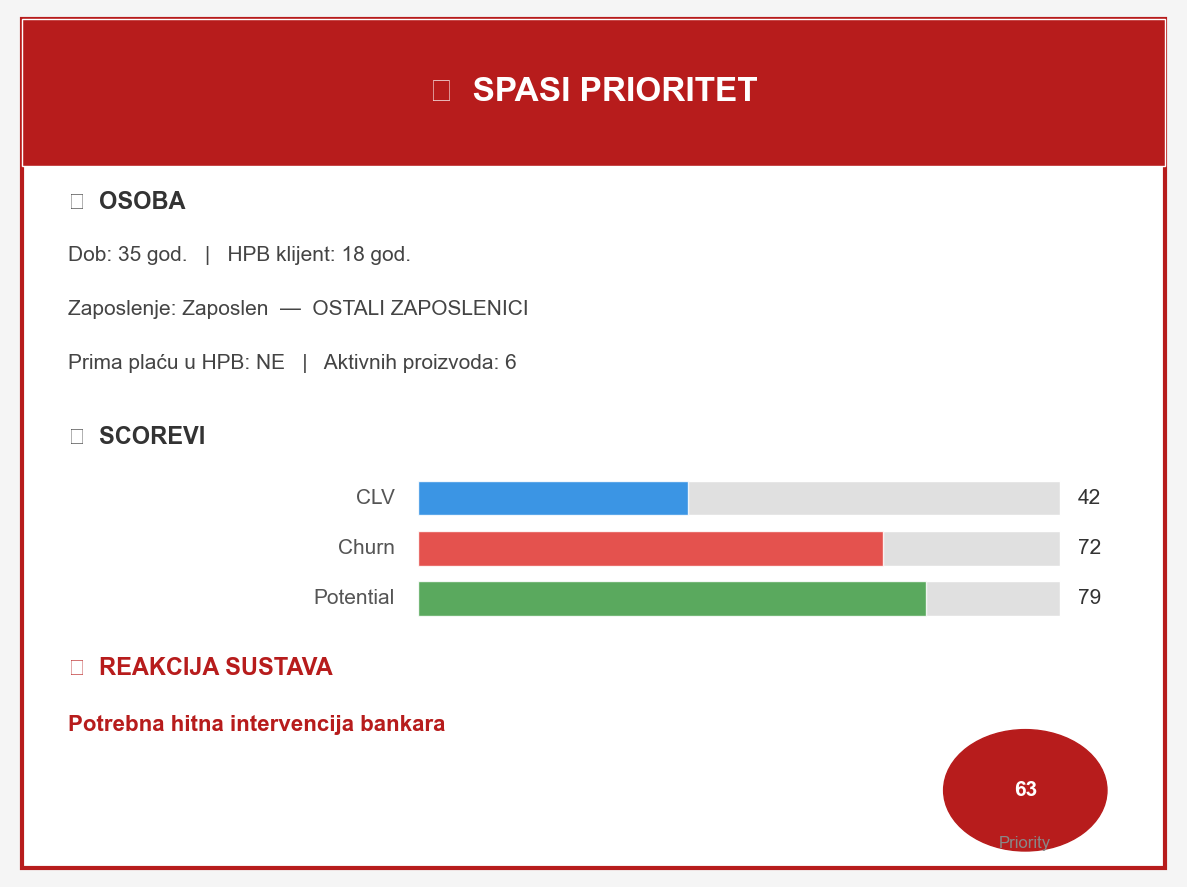

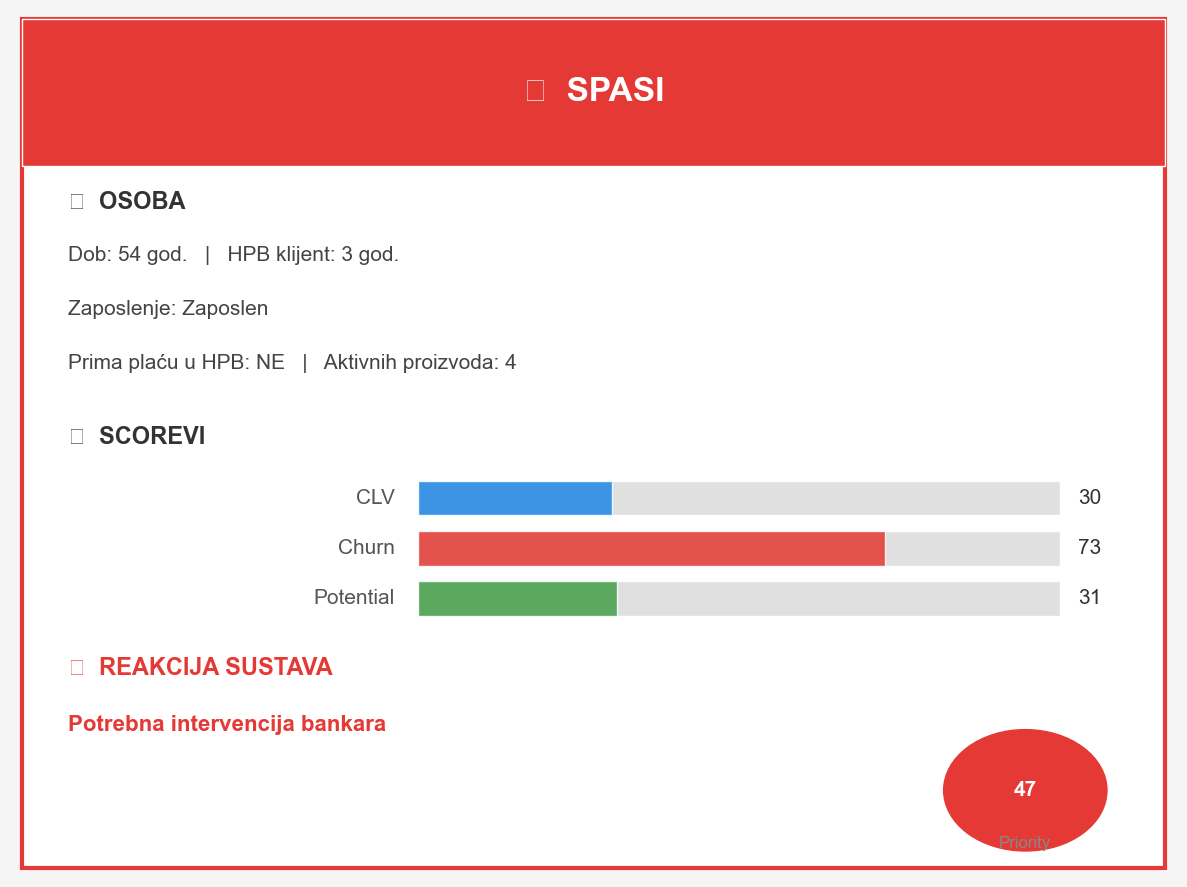

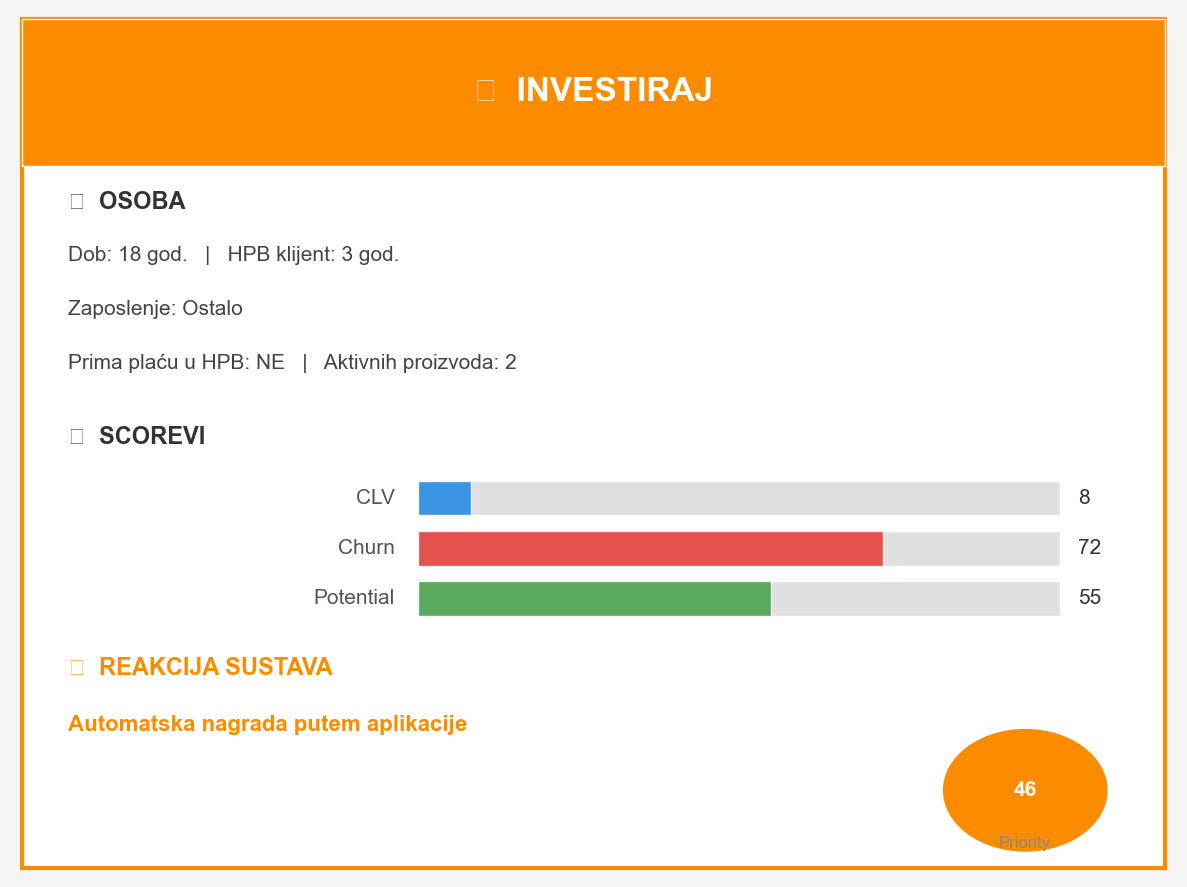

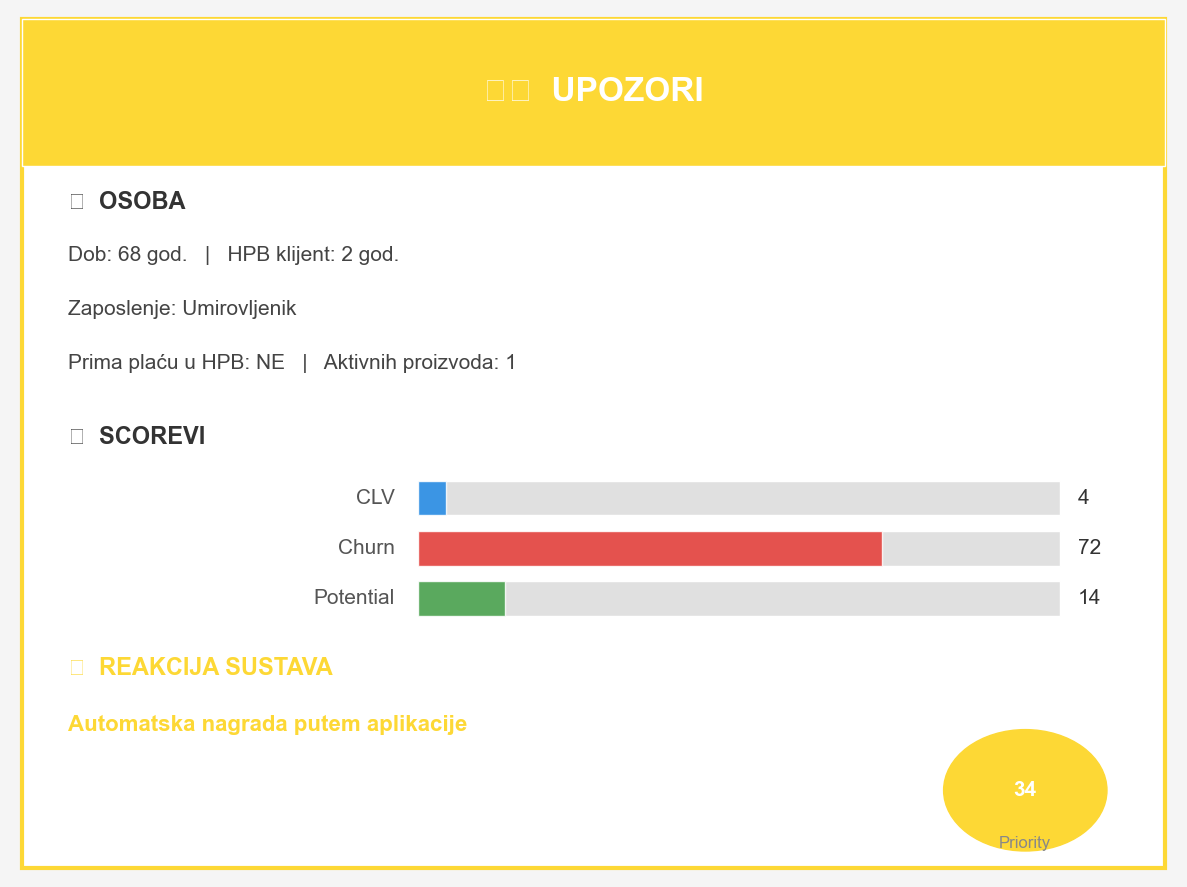

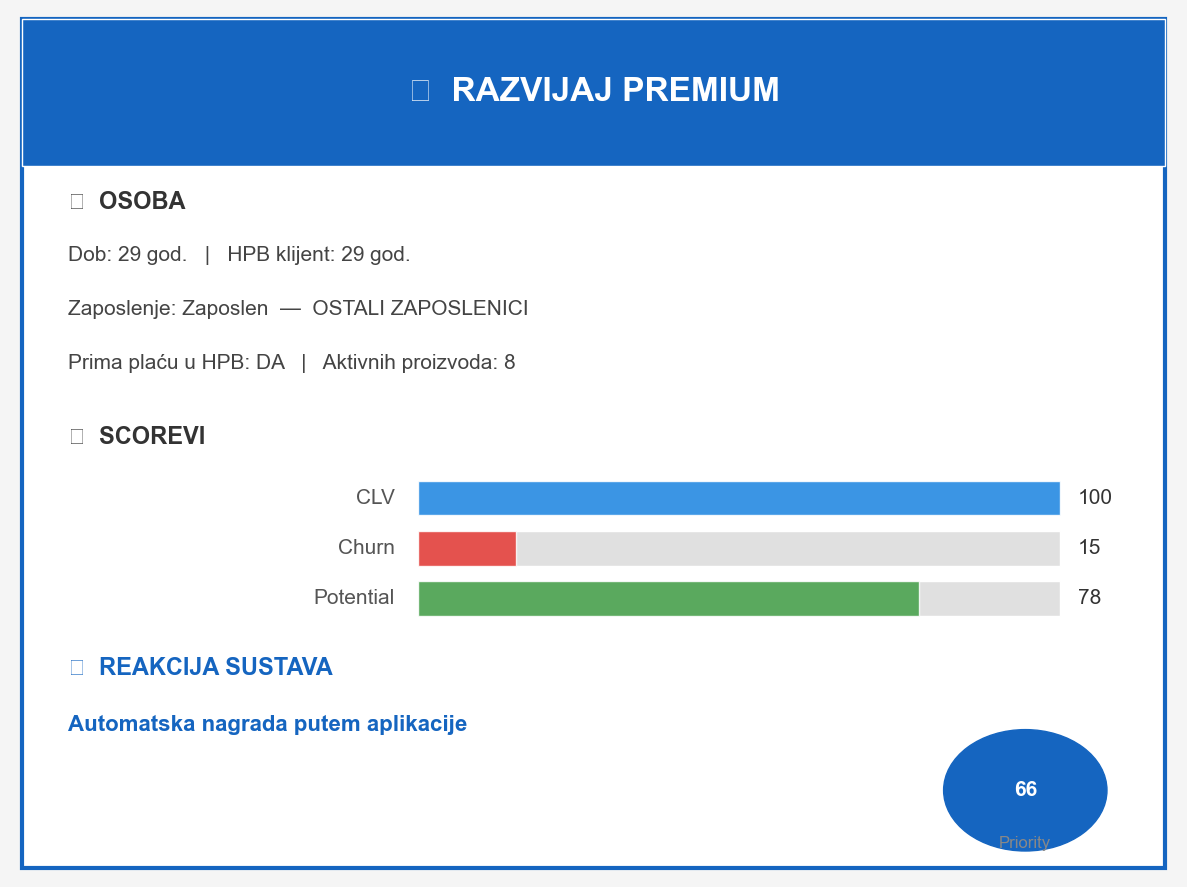

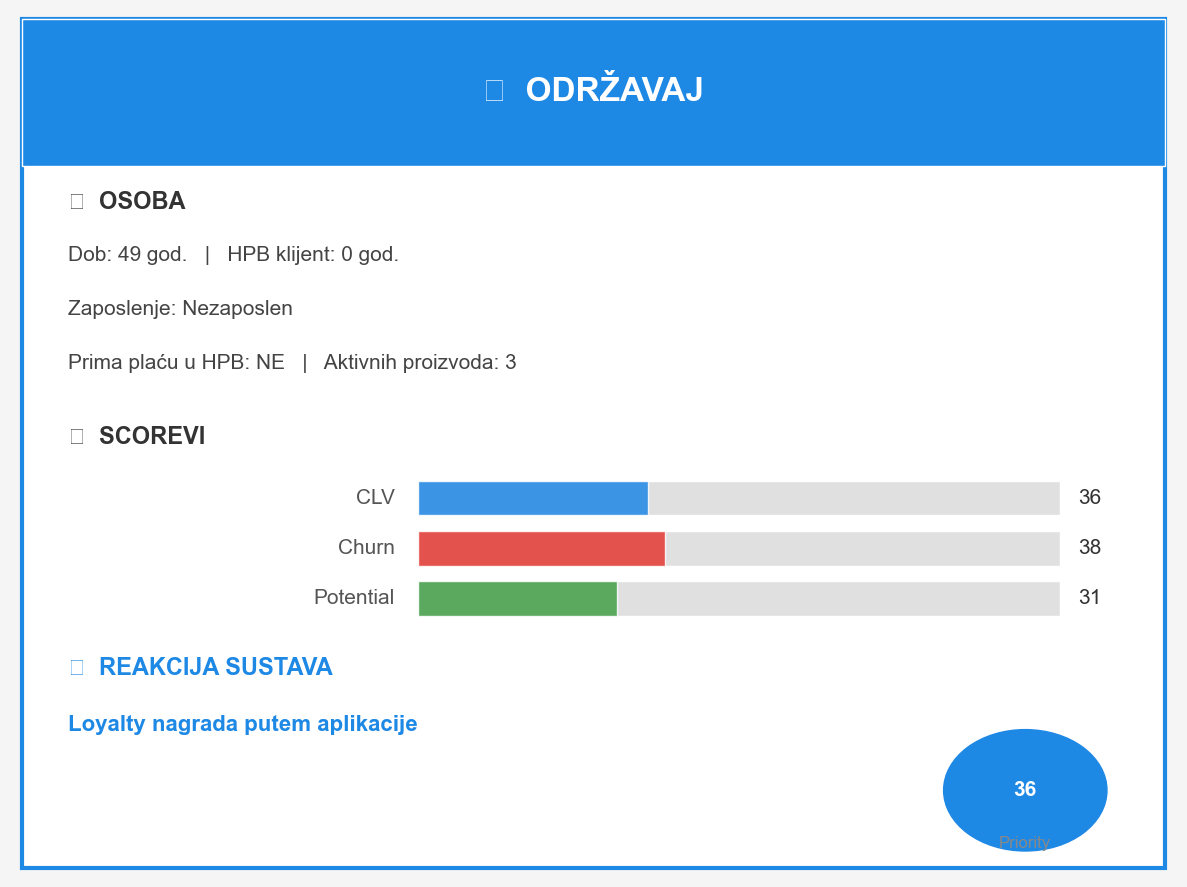

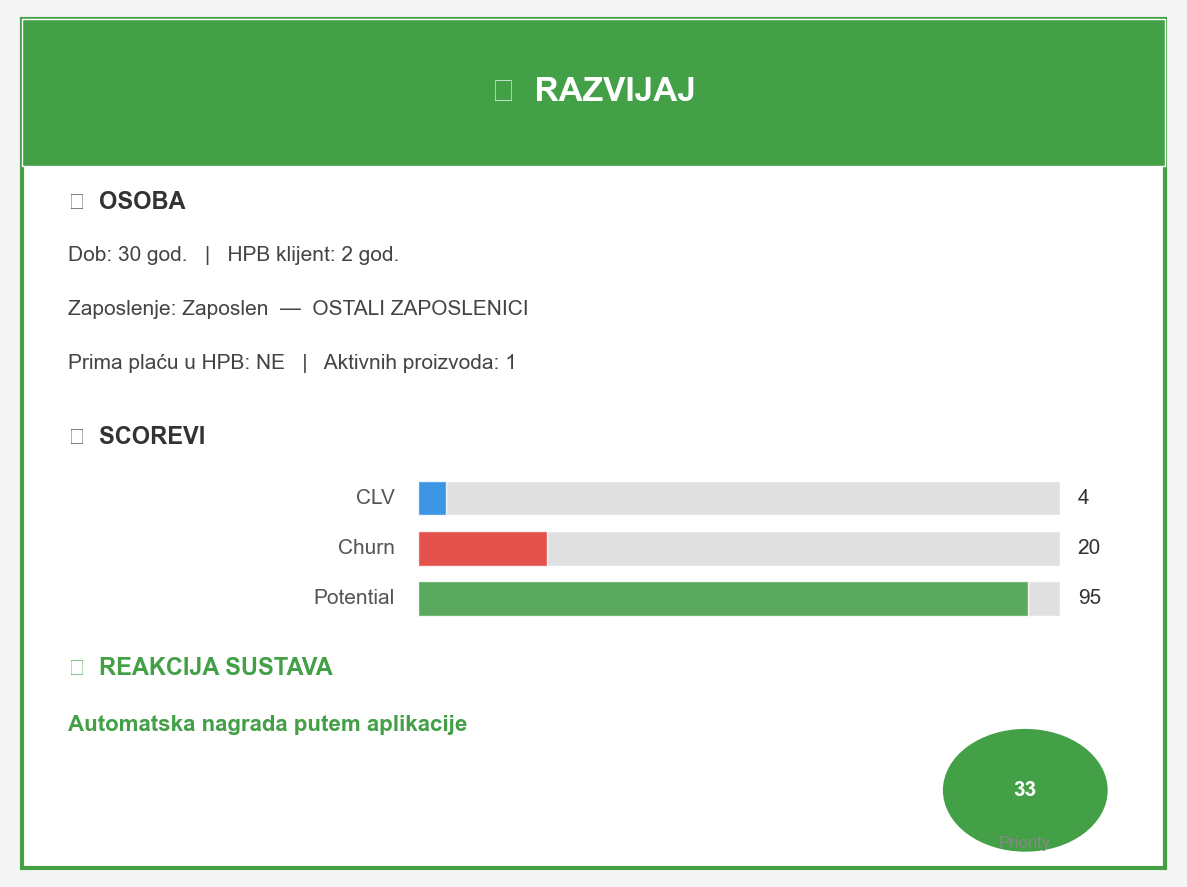

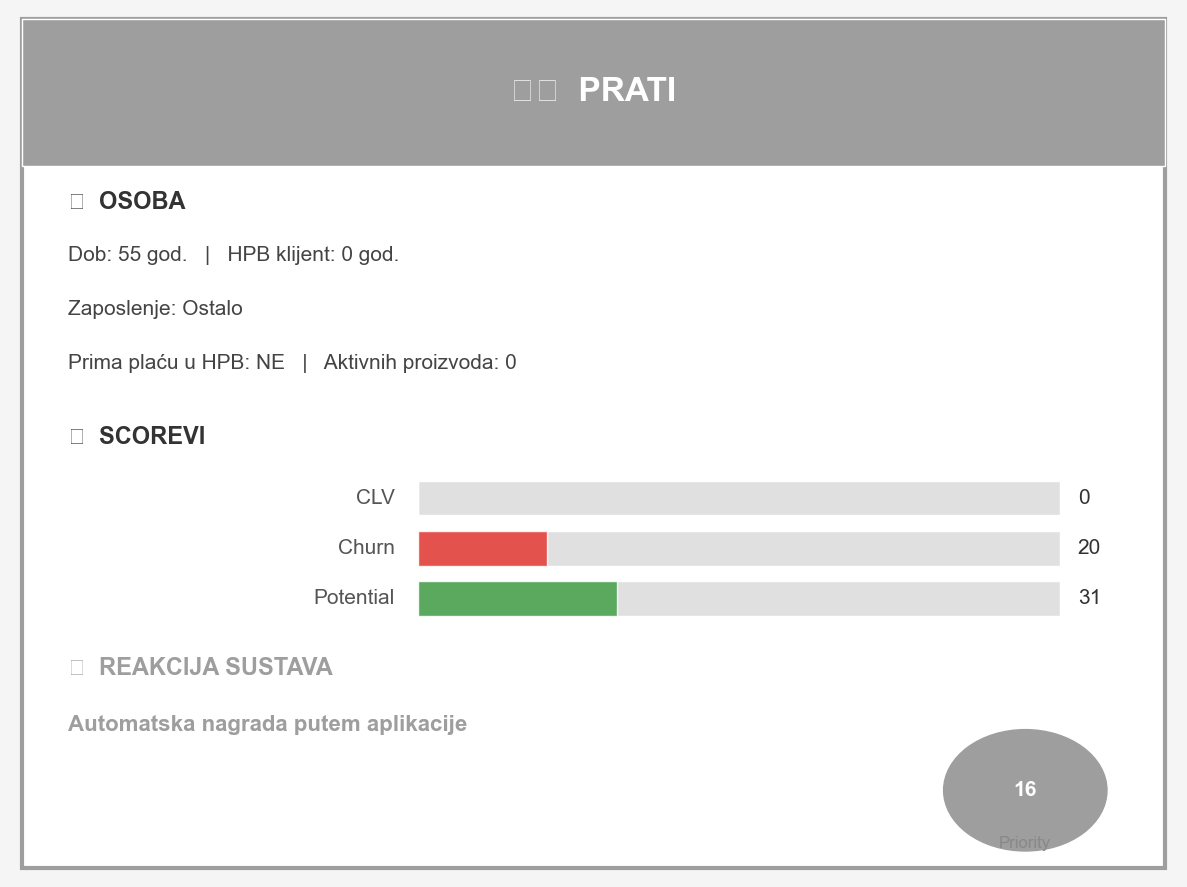



════════════════════════════════════════════════════════════════════════════════
  DETALJNA ANALIZA FAKTORA — TOP 20 KLIJENATA
════════════════════════════════════════════════════════════════════════════════

📊 CLV FAKTORI (trenutna vrijednost)
────────────────────────────────────────────────────────────────────────────────
     Klijent          Segment  CLV Score  Br. proizvoda  Ima kredit  Prima plaću  Avg vol/mj (€)  Avg stanje (€)  Tenure (god)
T0841J3T388A RAZVIJAJ PREMIUM       83.5           10.0         1.0          1.0          7268.0          -644.0          10.2
QUELJIJ5M37F RAZVIJAJ PREMIUM      100.0            8.0         1.0          1.0         16736.9         13243.8          29.4
JTX3RX0WK9AG RAZVIJAJ PREMIUM       93.5           14.0         1.0          1.0         21930.3         31681.7          10.2
QEAUO75VWZNM RAZVIJAJ PREMIUM       83.5            7.0         1.0          1.0          6333.3         -2684.7          10.1
FCQLJVYHUREL RAZVIJAJ PREMIUM       8

In [12]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass

"""
HPB Hackathon 2026 — Zadatak 1
AI Sustav za Predviđanje Odlaska Klijenata i Retencijske Mjere

Scoring Framework:
  1. CLV Score         — trenutna vrijednost klijenta
  2. Churn Risk Score  — rizik odlaska
  3. Future Potential  — budući potencijal
  4. Priority Score    — kombinacija za poslovnu odluku + akciju
"""

import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

import os
_win  = r"C:\Users\Lovre Marković\Documents\Kakaton\OneDrive_2026-04-16" + "\\"
_wsl  = "/mnt/c/Users/Lovre Marković/Documents/Kakaton/OneDrive_2026-04-16/"
DATA_PATH = _win if os.path.exists(_win) else _wsl

# Težine Priority Score
W_CHURN     = 0.40
W_CLV       = 0.35
W_POTENTIAL = 0.25

# Pragovi za segmentaciju
CHURN_THRESHOLD = 60   # iznad = visoki rizik


# ════════════════════════════════════════════════════════════
# POMOĆNE FUNKCIJE
# ════════════════════════════════════════════════════════════

def parse_hr_date(series):
    """Parsira hrvatski format datuma: D/M/YYYY/ ili D/M/YYYY/ H:MM:SS"""
    cleaned = (series.astype(str)
               .str.strip()
               .str.replace(r'/\s*$', '', regex=True)
               .str.strip())
    return pd.to_datetime(cleaned, dayfirst=True, errors='coerce')

def load_numeric(series):
    """Pretvara broj s decimalnom zarezom u float: '195,17' → 195.17"""
    return pd.to_numeric(
        series.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

def normalize(series, cap_pct=95):
    """Normalizira seriju na [0, 1], cap na određeni percentil."""
    cap = series.quantile(cap_pct / 100)
    if cap == 0:
        return pd.Series(0, index=series.index)
    return (series.clip(0, cap) / cap).clip(0, 1)


# ════════════════════════════════════════════════════════════
# 1. UČITAVANJE PODATAKA
# ════════════════════════════════════════════════════════════

print("=" * 62)
print("  HPB HACKATHON — Churn Prevention System")
print("=" * 62)
print("\n[1/9] Učitavanje podataka...")

klijenti = pd.read_csv(
    DATA_PATH + "HACKATHON ZICER 202604 KLIJENTI.csv",
    sep=';', encoding='cp1250', on_bad_lines='skip', low_memory=False)

proizvodi = pd.read_csv(
    DATA_PATH + "HACKATHON ZICER 202604 PROIZVODI.csv",
    sep=';', encoding='cp1250', on_bad_lines='skip', low_memory=False)

stanja = pd.read_csv(
    DATA_PATH + "HACKATHON ZICER 202604 STANJA PROIZVODA.csv",
    sep=';', encoding='cp1250', on_bad_lines='skip', low_memory=False)

transakcije = pd.read_csv(
    DATA_PATH + "HACKATHON ZICER 202604 TRANSAKCIJE.csv",
    sep=';', encoding='cp1250', on_bad_lines='skip', low_memory=False,
    index_col=False)

cc = pd.read_csv(
    DATA_PATH + "HACKATHON ZICER 202604 KONTAKT CENTAR.csv",
    sep=';', encoding='cp1250', on_bad_lines='skip', low_memory=False)

print(f"  ✓ Klijenti:        {len(klijenti):>8,}")
print(f"  ✓ Proizvodi:       {len(proizvodi):>8,}")
print(f"  ✓ Stanja:          {len(stanja):>8,}")
print(f"  ✓ Transakcije:     {len(transakcije):>8,}")
print(f"  ✓ Kontakt centar:  {len(cc):>8,}")


# ════════════════════════════════════════════════════════════
# 2. PARSIRANJE TIPOVA I DATUMA
# ════════════════════════════════════════════════════════════

print("\n[2/9] Parsiranje tipova i datuma...")

# Datumi
proizvodi['DATUM_OTVARANJA']  = parse_hr_date(proizvodi['DATUM_OTVARANJA'])
proizvodi['DATUM_ZATVARANJA'] = parse_hr_date(proizvodi['DATUM_ZATVARANJA'])

transakcije['DATUM']  = parse_hr_date(transakcije['DATUM_I_VRIJEME_TRANSAKCIJE'])
transakcije['IZNOS']  = load_numeric(transakcije['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'])

stanja['VRIJEDI_OD']  = parse_hr_date(stanja['VRIJEDI_OD'])
stanja['STANJE']      = load_numeric(stanja['STANJE_U_DOMICILNOJ_VALUTI'])

cc['DATUM_CC']        = parse_hr_date(cc['VRIJEME_KREIRANJA'])

klijenti['DATUM_ODNOSA'] = parse_hr_date(klijenti['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA'])

# Referentni datum = zadnja realna transakcija (filtriraj outliere)
valid_dates = transakcije['DATUM'][transakcije['DATUM'] < pd.Timestamp('2030-01-01')]
REF_DATE = valid_dates.max() if len(valid_dates) > 0 else pd.Timestamp('2025-09-30')
print(f"  ✓ Referentni datum: {REF_DATE.date()}")

# Mapiraj proizvod → klijent (za join s transakcijama i stanjima)
prod_to_client = (proizvodi[['IDENTIFIKATOR_PROIZVODA', 'IDENTIFIKATOR_KLIJENTA']]
                  .drop_duplicates('IDENTIFIKATOR_PROIZVODA'))

transakcije = transakcije.merge(prod_to_client, on='IDENTIFIKATOR_PROIZVODA', how='left')
stanja      = stanja.merge(prod_to_client, on='IDENTIFIKATOR_PROIZVODA', how='left')

print("  ✓ Joinovi postavljeni")


# ════════════════════════════════════════════════════════════
# 3. CLV SCORE  (max 100 bodova)
# ════════════════════════════════════════════════════════════
# Komponente:
#   Aktivnih proizvoda   → 25 bod  (više = veća vezanost)
#   Ima kredit           → 20 bod  (najvrjedniji proizvod)
#   Prima plaću u HPB    → 20 bod  (strateški ključno)
#   Avg monthly volume   → 15 bod  (transakcijska vrijednost)
#   Avg balance 90d      → 10 bod  (depozitna baza)
#   Tenure               → 10 bod  (lojalnost)
# ════════════════════════════════════════════════════════════

print("\n[3/9] Računanje CLV Score...")

# Aktivni proizvodi = nisu zatvoreni, ili su zatvoreni unutar zadnjih 6 mj.
aktivni = proizvodi[
    (proizvodi['DATUM_ZATVARANJA'].isna()) |
    (proizvodi['DATUM_ZATVARANJA'] >= REF_DATE - pd.Timedelta(days=180))
].copy()

clv = (aktivni.groupby('IDENTIFIKATOR_KLIJENTA')
       .agg(aktivnih_proizvoda=('IDENTIFIKATOR_PROIZVODA', 'nunique'))
       .reset_index())

# Boolean flagovi po domeni
for domain, col in [
    ('KREDITI',  'has_kredit'),
    ('DEPOZITI', 'has_depozit'),
    ('KARTICE',  'has_kartica'),
    ('KANALI',   'has_digitalni'),
]:
    ids_s_domenom = set(aktivni[aktivni['NAZIV_DOMENE_PROIZVODA'] == domain]['IDENTIFIKATOR_KLIJENTA'])
    clv[col] = clv['IDENTIFIKATOR_KLIJENTA'].isin(ids_s_domenom).astype(int)

# Prosječni mjesečni transakcijski volumen (zadnjih 12 mj.)
t12 = transakcije[transakcije['DATUM'] >= REF_DATE - pd.Timedelta(days=365)]
txn_vol = (t12.groupby('IDENTIFIKATOR_KLIJENTA')['IZNOS']
           .sum()
           .div(12)
           .rename('avg_monthly_vol')
           .reset_index())
clv = clv.merge(txn_vol, on='IDENTIFIKATOR_KLIJENTA', how='left')

# Prosječno stanje zadnjih 90 dana
s90 = stanja[stanja['VRIJEDI_OD'] >= REF_DATE - pd.Timedelta(days=90)]
avg_bal = (s90.groupby('IDENTIFIKATOR_KLIJENTA')['STANJE']
           .mean()
           .rename('avg_balance_90d')
           .reset_index())
clv = clv.merge(avg_bal, on='IDENTIFIKATOR_KLIJENTA', how='left')

# Tenure
klijenti['tenure_years'] = (REF_DATE - klijenti['DATUM_ODNOSA']).dt.days / 365
clv = clv.merge(
    klijenti[['IDENTIFIKATOR_KLIJENTA', 'tenure_years',
              'KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI']],
    on='IDENTIFIKATOR_KLIJENTA', how='left')
clv = clv.fillna(0)
clv['prima_placu'] = (clv['KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI'] == 'DA').astype(int)

# CLV Score
clv['CLV_SCORE'] = (
    normalize(clv['aktivnih_proizvoda']) * 25 +
    clv['has_kredit']    * 20 +
    clv['prima_placu']   * 20 +
    normalize(clv['avg_monthly_vol'])  * 15 +
    normalize(clv['avg_balance_90d'])  * 10 +
    normalize(clv['tenure_years'])     * 10
).clip(0, 100)

print(f"  ✓ CLV Score — prosjek: {clv['CLV_SCORE'].mean():.1f}  "
      f"medijan: {clv['CLV_SCORE'].median():.1f}")


# ════════════════════════════════════════════════════════════
# 4. CHURN RISK SCORE  (max 100 bodova)
# ════════════════════════════════════════════════════════════
# Komponente:
#   Pad frekvencije txn (30d vs prev 30d)  → 25 bod
#   Neaktivnost (dani od zadnje txn)       → 20 bod
#   Pad stanja računa (trend)              → 20 bod
#   Pad volumena txn                       → 15 bod
#   Prigovori u CC (zadnjih 6 mj.)         → 10 bod
#   Niska digitalna aktivnost              → 10 bod
#
# BINDING FAKTOR: klijenti s aktivnim kreditom  → cap 45
# (ne mogu otići, ali mogu funkcionalno churnat)
# ════════════════════════════════════════════════════════════

print("\n[4/9] Računanje Churn Risk Score...")

# Vremenski prozori transakcija
t30   = transakcije[transakcije['DATUM'] >= REF_DATE - pd.Timedelta(days=30)]
t_pre = transakcije[
    (transakcije['DATUM'] >= REF_DATE - pd.Timedelta(days=60)) &
    (transakcije['DATUM'] <  REF_DATE - pd.Timedelta(days=30))
]
t90   = transakcije[transakcije['DATUM'] >= REF_DATE - pd.Timedelta(days=90)]

txn_30   = t30.groupby('IDENTIFIKATOR_KLIJENTA')['IZNOS'].count().rename('cnt_30')
txn_pre  = t_pre.groupby('IDENTIFIKATOR_KLIJENTA')['IZNOS'].count().rename('cnt_pre')
vol_30   = t30.groupby('IDENTIFIKATOR_KLIJENTA')['IZNOS'].sum().rename('vol_30')
vol_pre  = t_pre.groupby('IDENTIFIKATOR_KLIJENTA')['IZNOS'].sum().rename('vol_pre')
last_txn = (transakcije.groupby('IDENTIFIKATOR_KLIJENTA')['DATUM']
            .max().rename('last_txn'))

# Digitalni omjer (KANAL: D = Digital, C = Counter/šalter)
cnt_total   = t90.groupby('IDENTIFIKATOR_KLIJENTA')['IZNOS'].count().rename('cnt_total_90')
cnt_digital = (t90[t90['KANAL'] == 'D']
               .groupby('IDENTIFIKATOR_KLIJENTA')['IZNOS'].count()
               .rename('cnt_digital_90'))

# Stanje trend
s_rec = stanja[stanja['VRIJEDI_OD'] >= REF_DATE - pd.Timedelta(days=30)]
s_old = stanja[
    (stanja['VRIJEDI_OD'] >= REF_DATE - pd.Timedelta(days=90)) &
    (stanja['VRIJEDI_OD'] <  REF_DATE - pd.Timedelta(days=30))
]
bal_rec = s_rec.groupby('IDENTIFIKATOR_KLIJENTA')['STANJE'].mean().rename('bal_rec')
bal_old = s_old.groupby('IDENTIFIKATOR_KLIJENTA')['STANJE'].mean().rename('bal_old')

# Prigovori (zadnjih 6 mj.)
prigovori = (cc[
    (cc['DATUM_CC'] >= REF_DATE - pd.Timedelta(days=180)) &
    (cc['TIP_PREDMETA'] == 'Prigovor')
].groupby('IDENTIFIKATOR_KLIJENTA').size().rename('prigovori_6m'))

# Skupi sve u jedan DataFrame
churn = klijenti[['IDENTIFIKATOR_KLIJENTA']].copy()
for s in [txn_30, txn_pre, vol_30, vol_pre, last_txn,
          cnt_total, cnt_digital, bal_rec, bal_old, prigovori]:
    churn = churn.join(s, on='IDENTIFIKATOR_KLIJENTA')
# Izvedeni signali — izračunaj PRIJE fillna jer last_txn mora biti datetime
churn['days_since_txn'] = (REF_DATE - churn['last_txn']).dt.days.fillna(180)

churn = churn.fillna(0)
churn['freq_drop'] = np.where(
    churn['cnt_pre'] > 0,
    (1 - churn['cnt_30'] / churn['cnt_pre']).clip(0, 1), 0)
churn['vol_drop'] = np.where(
    churn['vol_pre'] > 0,
    (1 - churn['vol_30'] / churn['vol_pre']).clip(0, 1), 0)
churn['bal_drop'] = np.where(
    churn['bal_old'] > 0,
    (1 - churn['bal_rec'] / churn['bal_old']).clip(0, 1), 0)
churn['digital_ratio'] = np.where(
    churn['cnt_total_90'] > 0,
    churn['cnt_digital_90'] / churn['cnt_total_90'], 0.5)

# Churn Risk Score
churn['CHURN_RISK'] = (
    churn['freq_drop']                         * 25 +
    (churn['days_since_txn'].clip(0, 90) / 90) * 20 +
    churn['bal_drop']                          * 20 +
    churn['vol_drop']                          * 15 +
    (churn['prigovori_6m'].clip(0, 3) / 3)     * 20
).clip(0, 100)

# Binding faktor — klijenti s kreditom ne mogu zaista otići (cap 45)
has_kredit_ids = set(clv[clv['has_kredit'] == 1]['IDENTIFIKATOR_KLIJENTA'])
churn['ima_kredit'] = churn['IDENTIFIKATOR_KLIJENTA'].isin(has_kredit_ids).astype(int)
churn['CHURN_RISK'] = np.where(
    churn['ima_kredit'] == 1,
    churn['CHURN_RISK'].clip(0, 45),
    churn['CHURN_RISK'])

print(f"  ✓ Churn Risk Score — prosjek: {churn['CHURN_RISK'].mean():.1f}  "
      f"medijan: {churn['CHURN_RISK'].median():.1f}")
print(f"  ✓ Klijenata s kreditom (binding cap): "
      f"{churn['ima_kredit'].sum():,} "
      f"({100*churn['ima_kredit'].mean():.1f}%)")


# ════════════════════════════════════════════════════════════
# 5. FUTURE POTENTIAL SCORE  (max 100 bodova)
# ════════════════════════════════════════════════════════════
# Komponente:
#   Dob (mlađi = veći potencijal)              → 25 bod
#   Vrsta posla / zanimanje                    → 25 bod  ← NOVO
#   Stručna sprema                             → 20 bod
#   Cross-sell gap (nema kredit, ima prihode)  → 20 bod
#   Obiteljski status                          → 10 bod
#
# Umirovljenici: sve × 0.5 (niži ali ne nulti potencijal)
# ════════════════════════════════════════════════════════════

print("\n[5/9] Računanje Future Potential Score...")

potential = klijenti[[
    'IDENTIFIKATOR_KLIJENTA', 'DOB', 'VRSTA_ZAPOSLENJA',
    'ZANIMANJE', 'KATEGORIJA_POSLODAVCA', 'TIP_POSLODAVCA',
    'STRUCNA_SPREMA', 'BRACNI_STATUS',
    'BROJ_UZDRZAVANIH_CLANOVA_KUCANSTVA'
]].copy()

# ── Dob score (max 25) ───────────────────────────────────────────────────────
potential['age_score'] = np.where(potential['DOB'] <= 30, 25,
                          np.where(potential['DOB'] <= 40, 20,
                          np.where(potential['DOB'] <= 50, 12,
                          np.where(potential['DOB'] <= 60, 6, 2))))

# ── Job score (max 25) — vrsta posla kao prediktor budućih prihoda ──────────
def job_score(row):
    vrsta      = str(row.get('VRSTA_ZAPOSLENJA',    '')).upper()
    zanimanje  = str(row.get('ZANIMANJE',           '')).upper()
    kategorija = str(row.get('KATEGORIJA_POSLODAVCA','')).upper()
    tip        = str(row.get('TIP_POSLODAVCA',      '')).upper()

    # Tier 1 — iznimno visoki prihodi (25 bod)
    if 'POMORAC' in vrsta:
        return 25   # pomorci: inozemna primanja, bez troška života na brodu
    if any(x in zanimanje for x in ['MENADŽER', 'DOKTOR', 'ZUBAR', 'ODVJETNIK']):
        return 25   # slobodne profesije i menadžment
    if 'SLOBODNO ZANIMANJE' in kategorija or 'LIJEČNIK' in kategorija or 'ODVJETNIK' in kategorija:
        return 25

    # Tier 2 — visoki prihodi s rastom (22 bod)
    if vrsta in ('PODUZETNIK', 'SAMOZAPOSLEN'):
        return 22   # prihodi rastu s biznisom
    if 'STRANI BROD' in kategorija:
        return 22   # offshore/inozemna primanja

    # Tier 3 — privatni sektor, rast plaće moguć (18 bod)
    if 'PRIVATNO PODUZEĆE - VELIKO' in tip:
        return 18   # velike firme → napredovanje, bonusi
    if any(x in kategorija for x in ['D.D. PRIVATNO', 'BANKA', 'OSIGURANJE']):
        return 18

    # Tier 4 — privatni sektor, srednji rast (14 bod)
    if any(x in tip for x in ['PRIVATNO PODUZEĆE - SREDNJE', 'PRIVATNO PODUZEĆE - MALO']):
        return 14
    if any(x in kategorija for x in ['D.O.O. PRIVATNO', 'J.D.O.O.', 'K.D. PRIVATNO']):
        return 14
    if 'OBRTNIK' in vrsta or 'OBRT' in tip or 'OBRT' in kategorija:
        return 12   # obrtnici: varijabilno, ali samostalno

    # Tier 5 — javni sektor / stabilno (10 bod)
    if 'JAVNO PODUZEĆE' in tip:
        return 10
    if any(x in zanimanje for x in ['JAVNO PODUZEĆ', 'NASTAVNIK', 'PROFESOR', 'ODGOJITELJ']):
        return 10

    # Tier 6 — državna uprava (7 bod)
    if any(x in zanimanje for x in ['DRŽAVNI SLUŽBENIK', 'JAVNA USTANOVA']):
        return 7
    if 'DRŽAVNO' in kategorija or 'DRŽAVNA UPRAVA' in kategorija or 'MINISTARSTVO' in kategorija:
        return 7

    # Tier 7 — honorarac / varijabilno (8 bod)
    if 'HONORARAC' in vrsta or 'HONORARAC' in tip:
        return 8

    # Tier 8 — nezaposlen / student / ostalo (4 bod)
    if vrsta in ('NEZAPOSLEN', 'STUDENT'):
        return 4

    return 10   # default — zaposlen ali bez detaljnijih podataka

potential['job_score'] = potential.apply(job_score, axis=1)

# ── Edukacija score (max 20) ─────────────────────────────────────────────────
def edu_score(sprema):
    sprema = str(sprema).upper()
    if any(x in sprema for x in ['VSS', 'VŠS', 'MAGISTAR', 'DOKTOR', 'SVEUČILIŠNI']):
        return 20
    if 'STRUČNI' in sprema:
        return 14
    if 'SSS' in sprema:
        return 9
    return 5

potential['edu_score'] = potential['STRUCNA_SPREMA'].apply(edu_score)

# ── Obiteljski status (max 10) ───────────────────────────────────────────────
potential['family_score'] = np.where(
    potential['BRACNI_STATUS'].astype(str).str.upper().str.contains('ŽENJEN|UDANA|BRAKU', na=False),
    10, 5)

# ── Cross-sell gap (max 20) ─────────────────────────────────────────────────
# Klijent s prihodima ali bez kredita = potencijalni kandidat za hipoteku/kredit
clv_mini = clv[['IDENTIFIKATOR_KLIJENTA', 'has_kredit', 'has_depozit', 'aktivnih_proizvoda']]
potential = potential.merge(clv_mini, on='IDENTIFIKATOR_KLIJENTA', how='left')
potential['crossell_score'] = np.where(
    (potential['has_kredit'] == 0) & (potential['job_score'] >= 14), 20,
    np.where((potential['has_depozit'] == 0) & (potential['age_score'] >= 12), 10, 5))

# ── Ukupni Future Potential ──────────────────────────────────────────────────
potential['FUTURE_POTENTIAL'] = (
    potential['age_score']    +   # max 25
    potential['job_score']    +   # max 25
    potential['edu_score']    +   # max 20
    potential['family_score'] +   # max 10
    potential['crossell_score']   # max 20
).clip(0, 100)

# Umirovljenici: skaliraj dolje (stabilni, ali ograničen budući potencijal)
umir_mask = potential['VRSTA_ZAPOSLENJA'].astype(str).str.upper().str.contains('UMIROVLJENIK', na=False)
potential.loc[umir_mask, 'FUTURE_POTENTIAL'] *= 0.5

print(f"  ✓ Future Potential Score — prosjek: {potential['FUTURE_POTENTIAL'].mean():.1f}  "
      f"medijan: {potential['FUTURE_POTENTIAL'].median():.1f}")

# Provjera: job_score distribucija
print(f"  ✓ Job score distribucija:")
job_dist = potential.groupby('job_score')['IDENTIFIKATOR_KLIJENTA'].count().sort_index(ascending=False)
for score, cnt in job_dist.items():
    print(f"     {score:>3} bod — {cnt:>5} klijenata")




# ════════════════════════════════════════════════════════════
# 7. PRIORITY SCORE & SEGMENTACIJA
# ════════════════════════════════════════════════════════════

print("\n[7/9] Izračun Priority Score i segmentacija...")

final = klijenti[['IDENTIFIKATOR_KLIJENTA', 'DOB', 'SPOL',
                   'VRSTA_ZAPOSLENJA', 'KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI']].copy()

final = (final
    .merge(clv[['IDENTIFIKATOR_KLIJENTA', 'CLV_SCORE', 'aktivnih_proizvoda',
                'has_kredit', 'has_depozit', 'prima_placu', 'tenure_years',
                'avg_monthly_vol', 'avg_balance_90d']],
           on='IDENTIFIKATOR_KLIJENTA', how='left')
    .merge(churn[['IDENTIFIKATOR_KLIJENTA', 'CHURN_RISK', 'days_since_txn',
                  'prigovori_6m', 'freq_drop', 'bal_drop', 'vol_drop', 'ima_kredit']],
           on='IDENTIFIKATOR_KLIJENTA', how='left')
    .merge(potential[['IDENTIFIKATOR_KLIJENTA', 'FUTURE_POTENTIAL',
                      'age_score', 'job_score', 'crossell_score']],
           on='IDENTIFIKATOR_KLIJENTA', how='left')
)
final = final.fillna(0)

# Priority Score s modifikatorima
final['PRIORITY_SCORE'] = (
    W_CHURN     * final['CHURN_RISK'] +
    W_CLV       * final['CLV_SCORE'] +
    W_POTENTIAL * final['FUTURE_POTENTIAL']
)
# Bonus modifikatori
final['PRIORITY_SCORE'] += np.where(final['prigovori_6m'] > 0, 10, 0)    # neriješeni prigovor
final['PRIORITY_SCORE'] += np.where(final['prima_placu'] == 1, 5, 0)      # prima plaću
final['PRIORITY_SCORE'] = final['PRIORITY_SCORE'].clip(0, 100)

# ════════════════════════════════════════════════════════════
# 3D SEGMENTACIJA: Churn Risk × CLV × Future Potential
# ════════════════════════════════════════════════════════════
#
#  8 segmenata (2 × 2 × 2):
#
#  Churn  CLV   Potential   Segment            Logika
#  ─────────────────────────────────────────────────────────
#  V      V     V           SPASI PRIORITET    zlatni klijent koji odlazi — sve resurse
#  V      V     N           SPASI              vrijedan klijent, rizik odlaska
#  V      N     V           INVESTIRAJ         mlad/potencijalan, još nizak CLV — gradi odnos
#  V      N     N           UPOZORI            odlazi, ali nije isplativo investirati mnogo
#  N      V     V           RAZVIJAJ PREMIUM   siguran + vrijedan + potencijal → cross-sell
#  N      V     N           ODRŽAVAJ           siguran, vrijedan → loyalty
#  N      N     V           RAZVIJAJ           nizak CLV, ali potencijal za rast
#  N      N     N           PRATI              monitoring, bez aktivne akcije
# ════════════════════════════════════════════════════════════

clv_med = final['CLV_SCORE'].median()
pot_med = final['FUTURE_POTENTIAL'].median()

def segmentiraj_3d(row):
    high_churn = row['CHURN_RISK']       > CHURN_THRESHOLD   # >60
    high_clv   = row['CLV_SCORE']        > clv_med
    high_pot   = row['FUTURE_POTENTIAL'] > pot_med

    if   high_churn and high_clv  and high_pot:  return 'SPASI PRIORITET'
    elif high_churn and high_clv  and not high_pot: return 'SPASI'
    elif high_churn and not high_clv and high_pot:  return 'INVESTIRAJ'
    elif high_churn and not high_clv and not high_pot: return 'UPOZORI'
    elif not high_churn and high_clv and high_pot:  return 'RAZVIJAJ PREMIUM'
    elif not high_churn and high_clv and not high_pot: return 'ODRŽAVAJ'
    elif not high_churn and not high_clv and high_pot: return 'RAZVIJAJ'
    else: return 'PRATI'

final['SEGMENT'] = final.apply(segmentiraj_3d, axis=1)

# Preporučene akcije po segmentu
AKCIJE = {
    'SPASI PRIORITET': '🚨  Potrebna hitna intervencija bankara',
    'SPASI':           '📞  Potrebna intervencija bankara',
    'INVESTIRAJ':      '📱  Automatska nagrada putem aplikacije',
    'UPOZORI':         '📱  Automatska nagrada putem aplikacije',
    'RAZVIJAJ PREMIUM':'📱  Automatska nagrada putem aplikacije',
    'ODRŽAVAJ':        '📱  Loyalty nagrada putem aplikacije',
    'RAZVIJAJ':        '📱  Automatska nagrada putem aplikacije',
    'PRATI':           '📱  Automatska nagrada putem aplikacije',
}
BUDGET = {
    'SPASI PRIORITET': 'Neograničen',
    'SPASI':           'Visok',
    'INVESTIRAJ':      'Srednji',
    'UPOZORI':         'Minimalan',
    'RAZVIJAJ PREMIUM':'Visok',
    'ODRŽAVAJ':        'Nizak',
    'RAZVIJAJ':        'Minimalan',
    'PRATI':           'Nula',
}
final['PREPORUCENA_AKCIJA'] = final['SEGMENT'].map(AKCIJE)

# Ispis pregleda segmenata
SEG_ORDER = ['SPASI PRIORITET','SPASI','INVESTIRAJ','UPOZORI',
             'RAZVIJAJ PREMIUM','ODRŽAVAJ','RAZVIJAJ','PRATI']
print(f"\n  {'SEGMENT':<18} {'BROJ':>6}   {'AVG PRIORITY':>12}   {'BUDGET':<14} AKCIJA")
print("  " + "─" * 95)
for seg in SEG_ORDER:
    sub = final[final['SEGMENT'] == seg]
    if len(sub) == 0:
        continue
    print(f"  {seg:<18} {len(sub):>6}   {sub['PRIORITY_SCORE'].mean():>12.1f}"
          f"   {BUDGET[seg]:<14} {AKCIJE[seg]}")


# ════════════════════════════════════════════════════════════
# 8. VIZUALIZACIJE — DASHBOARD
# ════════════════════════════════════════════════════════════

print("\n[8/9] Generiranje vizualizacija...")

SEG_COLORS = {
    'SPASI PRIORITET': '#B71C1C',   # tamno crvena
    'SPASI':           '#E53935',   # crvena
    'INVESTIRAJ':      '#FB8C00',   # narančasta
    'UPOZORI':         '#FDD835',   # žuta
    'RAZVIJAJ PREMIUM':'#1565C0',   # tamno plava
    'ODRŽAVAJ':        '#1E88E5',   # plava
    'RAZVIJAJ':        '#43A047',   # zelena
    'PRATI':           '#9E9E9E',   # siva
}
final['boja'] = final['SEGMENT'].map(SEG_COLORS)

fig = plt.figure(figsize=(20, 13))
fig.suptitle('HPB Hackathon — Churn Prevention Dashboard', fontsize=17,
             fontweight='bold', y=0.98)

# ── 1. Distribucija scoreva ──────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
for score, color, label in [
    ('CLV_SCORE',       '#1E88E5', 'CLV Score'),
    ('CHURN_RISK',      '#E53935', 'Churn Risk'),
    ('FUTURE_POTENTIAL','#43A047', 'Future Potential'),
]:
    ax1.hist(final[score], bins=30, alpha=0.55, color=color, label=label, density=True)
ax1.set_title('Distribucija scoreva', fontweight='bold')
ax1.set_xlabel('Score (0–100)')
ax1.set_ylabel('Gustoća')
ax1.legend(fontsize=9)

# ── 2. Segmentacija — pie ────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
seg_counts = final['SEGMENT'].value_counts().reindex(SEG_ORDER, fill_value=0)
seg_counts = seg_counts[seg_counts > 0]
wedges, texts, autotexts = ax2.pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.0f%%',
    colors=[SEG_COLORS[s] for s in seg_counts.index],
    startangle=90,
    pctdistance=0.78,
)
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('Segmentacija klijenata', fontweight='bold')

# ── 3. CLV vs Churn Risk scatter ─────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(final['CLV_SCORE'], final['CHURN_RISK'],
            c=final['boja'], alpha=0.35, s=12, linewidths=0)
ax3.axhline(CHURN_THRESHOLD, color='red', ls='--', alpha=0.6, lw=1.2,
            label=f'Churn prag ({CHURN_THRESHOLD})')
ax3.axvline(clv_med, color='blue', ls='--', alpha=0.6, lw=1.2,
            label=f'CLV medijan ({clv_med:.0f})')
patches = [mpatches.Patch(color=v, label=k) for k, v in SEG_COLORS.items()]
ax3.legend(handles=patches, fontsize=7, loc='upper right')
ax3.set_xlabel('CLV Score')
ax3.set_ylabel('Churn Risk Score')
ax3.set_title('CLV × Churn Risk', fontweight='bold')

# ── 4. Future Potential vs Churn Risk ────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.scatter(final['FUTURE_POTENTIAL'], final['CHURN_RISK'],
            c=final['boja'], alpha=0.35, s=12, linewidths=0)
ax4.axhline(CHURN_THRESHOLD, color='red', ls='--', alpha=0.6, lw=1.2)
ax4.axvline(pot_med, color='green', ls='--', alpha=0.6, lw=1.2,
            label=f'Potential medijan ({pot_med:.0f})')
ax4.legend(handles=patches, fontsize=7, loc='upper right')
ax4.set_xlabel('Future Potential Score')
ax4.set_ylabel('Churn Risk Score')
ax4.set_title('Future Potential × Churn Risk', fontweight='bold')

# ── 5. Top 20 klijenata za akciju ────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
top20 = (final.nlargest(20, 'PRIORITY_SCORE')
         [['IDENTIFIKATOR_KLIJENTA', 'PRIORITY_SCORE', 'SEGMENT']]
         .reset_index(drop=True))
bar_colors = [SEG_COLORS[s] for s in top20['SEGMENT']]
ax5.barh(range(20), top20['PRIORITY_SCORE'], color=bar_colors, edgecolor='white', lw=0.5)
ax5.set_yticks(range(20))
ax5.set_yticklabels(
    [f"{i+1:>2}. {k[:10]}..." for i, k in enumerate(top20['IDENTIFIKATOR_KLIJENTA'])],
    fontsize=7)
ax5.set_xlabel('Priority Score')
ax5.set_title('Top 20 klijenata za akciju', fontweight='bold')
ax5.invert_yaxis()
ax5.set_xlim(0, 100)

# ── 6. CLV × Potential matrica (heatmap) ─────────────────
ax6 = fig.add_subplot(2, 3, 6)
matrix = pd.crosstab(
    pd.cut(final['CLV_SCORE'],
           bins=[0, 33, 66, 100],
           labels=['Nizak\nCLV', 'Srednji\nCLV', 'Visoki\nCLV']),
    pd.cut(final['FUTURE_POTENTIAL'],
           bins=[0, 33, 66, 100],
           labels=['Nizak\nPotencijal', 'Srednji\nPotencijal', 'Visoki\nPotencijal'])
)
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax6,
            linewidths=0.8, cbar_kws={'shrink': 0.75}, annot_kws={'size': 10})
ax6.set_title('CLV × Future Potential matrica\n(broj klijenata)', fontweight='bold')
ax6.set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96])
out_dashboard = DATA_PATH.replace('OneDrive_2026-04-16\\', '') + 'churn_dashboard.png'
plt.savefig(out_dashboard, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✓ Dashboard: churn_dashboard.png")


# ════════════════════════════════════════════════════════════
# 9. PRIČA JEDNOG KLIJENTA  (demonstracija)
# ════════════════════════════════════════════════════════════

print("\n[9/9] Priča jednog klijenta — Demo")
print("─" * 62)

# Odabir: klijent iz SPASI segmenta s najvišim Priority Scoreom
spasi = final[final['SEGMENT'] == 'SPASI']
demo_row = (spasi if len(spasi) > 0 else final).nlargest(1, 'PRIORITY_SCORE').iloc[0]
demo_id  = demo_row['IDENTIFIKATOR_KLIJENTA']

demo_kl  = klijenti[klijenti['IDENTIFIKATOR_KLIJENTA'] == demo_id].iloc[0]
demo_txn = (transakcije[transakcije['IDENTIFIKATOR_KLIJENTA'] == demo_id]
            .dropna(subset=['DATUM']).copy())

print(f"\n👤  Klijent:           {demo_id}")
print(f"    Dob:               {int(demo_kl.get('DOB', '?'))} godina")
print(f"    Zaposlenje:        {demo_kl.get('VRSTA_ZAPOSLENJA', '?')}")
print(f"    Tenure:            {demo_row['tenure_years']:.1f} godina u HPB-u")
print(f"    Prima plaću u HPB: {demo_kl.get('KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI', '?')}")
print(f"    Aktivnih proizvoda:{int(demo_row['aktivnih_proizvoda'])}")
print(f"    Ima kredit:        {'DA' if demo_row['has_kredit'] else 'NE'}")
print()
print(f"📊  SCOREVI:")
print(f"    CLV Score:          {demo_row['CLV_SCORE']:>5.1f} / 100")
print(f"    Churn Risk:         {demo_row['CHURN_RISK']:>5.1f} / 100  ⚠️")
print(f"    Future Potential:   {demo_row['FUTURE_POTENTIAL']:>5.1f} / 100")
print(f"    {'─'*28}")
print(f"    PRIORITY SCORE:     {demo_row['PRIORITY_SCORE']:>5.1f} / 100")
print()
print(f"🎯  SEGMENT:  {demo_row['SEGMENT']}")
print(f"💡  AKCIJA:   {demo_row['PREPORUCENA_AKCIJA']}")

# Vizualizacija transakcijskog trenda za demo klijenta
if len(demo_txn) >= 3:
    demo_txn['MJESEC'] = demo_txn['DATUM'].dt.to_period('M')
    monthly = (demo_txn.groupby('MJESEC')
               .agg(count=('IZNOS', 'count'), volume=('IZNOS', 'sum'))
               .reset_index())
    monthly['MJ_DT'] = monthly['MJESEC'].dt.to_timestamp()

    fig2, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig2.suptitle(
        f"Priča klijenta  {demo_id[:14]}…  |  "
        f"Segment: {demo_row['SEGMENT']}  |  "
        f"Priority Score: {demo_row['PRIORITY_SCORE']:.0f}",
        fontsize=13, fontweight='bold')

    # Frekvencija
    bar_cols = ['#F44336' if d >= REF_DATE - pd.Timedelta(days=90) else '#90CAF9'
                for d in monthly['MJ_DT']]
    ax_a.bar(monthly['MJ_DT'], monthly['count'], color=bar_cols, width=25, alpha=0.85)
    ax_a.axvline(REF_DATE - pd.Timedelta(days=90), color='red', ls='--',
                 alpha=0.7, label='Zadnjih 90 dana')
    ax_a.set_ylabel('Broj transakcija / mj.')
    ax_a.set_title('Frekvencija transakcija — vidljivi pad!', loc='left')
    ax_a.legend()

    # Volumen
    ax_b.fill_between(monthly['MJ_DT'], monthly['volume'], alpha=0.3, color='#E53935')
    ax_b.plot(monthly['MJ_DT'], monthly['volume'], color='#E53935', lw=2)
    ax_b.axvline(REF_DATE - pd.Timedelta(days=90), color='red', ls='--', alpha=0.7)
    ax_b.set_ylabel('Transakcijski volumen (EUR)')
    ax_b.set_title('Ukupni volumen — trend prema dolje!', loc='left')

    plt.tight_layout()
    out_story = DATA_PATH.replace('OneDrive_2026-04-16\\', '') + 'client_story.png'
    plt.savefig(out_story, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n  ✓ Client story: client_story.png")
else:
    print("\n  (Nema dovoljno transakcija za ovog klijenta — odaberi drugi)")

# ════════════════════════════════════════════════════════════
# EXPORT REZULTATA
# ════════════════════════════════════════════════════════════

output_cols = [
    'IDENTIFIKATOR_KLIJENTA', 'DOB', 'VRSTA_ZAPOSLENJA',
    'CLV_SCORE', 'CHURN_RISK', 'FUTURE_POTENTIAL', 'PRIORITY_SCORE',
    'SEGMENT', 'PREPORUCENA_AKCIJA',
    'aktivnih_proizvoda', 'has_kredit', 'tenure_years',
    'days_since_txn', 'prigovori_6m',
]
out_csv = DATA_PATH.replace('OneDrive_2026-04-16\\', '') + 'churn_results.csv'
(final[output_cols]
 .sort_values('PRIORITY_SCORE', ascending=False)
 .to_csv(out_csv, index=False, encoding='utf-8-sig'))

print(f"\n  ✓ Rezultati: churn_results.csv  ({len(final):,} klijenata)")
print("\n" + "=" * 62)
print("  ZAVRŠENO!")
print("=" * 62)


# ════════════════════════════════════════════════════════════
# ANALIZA POTROŠNJE — gdje klijenti troše novac
# ════════════════════════════════════════════════════════════

print("\n\n" + "═" * 70)
print("  ANALIZA POTROŠNJE — kategorije i partner mapa")
print("═" * 70)

# Mapiranje bankarskih MCC kategorija → partneri i tip ponude
PARTNER_MAPA = {
    # Hrana i dostava
    'DJELATNOSTI RESTORANA':                      ('Hrana & Restorani',  'Wolt / Bolt Food — 10% cashback na dostavu'),
    'USLUGE PREHRANE':                            ('Hrana & Restorani',  'Wolt / Bolt Food — 10% cashback na dostavu'),
    'PRIPREMANJE I USLUŽIVANJE HRANE I PIĆA':     ('Hrana & Restorani',  'Wolt / Bolt Food — 10% cashback na dostavu'),

    # Supermarketi i trgovine
    'TRGOVINA NA MALO':                           ('Supermarketi',       'Konzum / Spar — 5% cashback na tjedno pakiranje'),
    'TRGOVINA NA MALO PRETEŽNO PREHRAMBENIM':     ('Supermarketi',       'Konzum / Spar — 5% cashback na tjedno pakiranje'),
    'NESPECIJALIZIRANA TRGOVINA NA MALO':         ('Supermarketi',       'Konzum / Spar — 5% cashback na tjedno pakiranje'),

    # Gorivo i automobili
    'TRGOVINA NA MALO MOTORNIM GORIVIMA':         ('Gorivo',             'INA kartica — 0,10€ popust po litri goriva'),
    'POPRAVAK MOTORNIH VOZILA I MOTOCIKALA':      ('Automobili',         'Auto servis partner — 15% popust na servis'),

    # Putovanja i turizam
    'DJELATNOSTI PUTNIČKIH AGENCIJA':             ('Putovanja',          'Uniline / Valamar — extra 8% popust na aranžman'),
    'DJELATNOSTI SMJEŠTAJA':                      ('Putovanja',          'Booking.com partner — 5% cashback na rezervacije'),
    'ZRAČNI PRIJEVOZ':                            ('Putovanja',          'Croatia Airlines Miles — dvostruki bodovi'),

    # Zdravlje i ljekarne
    'DJELATNOSTI ZDRAVSTVENE ZAŠTITE':            ('Zdravlje',           'dm / Bipa — 10% popust na dermokozmetiku'),
    'DJELATNOSTI BOLNICA':                        ('Zdravlje',           'Medicinsko osiguranje partner — snižena premija'),
    'DJELATNOSTI ZDRAVSTVENE ZAŠTITE I SOCIJALNE SKRBI': ('Zdravlje',    'dm / Bipa — 10% popust na dermokozmetiku'),

    # Sport i rekreacija
    'SPORTSKE AKTIVNOSTI I ZABAVA':               ('Sport & Fitness',    'MultiSport kartica — 20% popust na godišnju'),
    'DJELATNOSTI FITNES CENTARA':                 ('Sport & Fitness',    'MultiSport kartica — 20% popust na godišnju'),

    # Odjeća i moda
    'TRGOVINA NA MALO ODJEĆOM':                  ('Moda',               'Zara / H&M partner — 10% na online kupnju'),
    'TRGOVINA NA MALO OBUĆOM':                    ('Moda',               'Zara / H&M partner — 10% na online kupnju'),

    # Elektronika i tehnologija
    'TRGOVINA NA MALO RAČUNALNOM OPREMOM':        ('Elektronika',        'Links / HG Spot — 8% popust na tehničku robu'),
    'TRGOVINA NA MALO TELEKOMUNIKACIJSKOM':        ('Elektronika',        'A1 / Telemach — posebna tarifa za HPB klijente'),

    # Obrazovanje
    'OBRAZOVANJE':                                ('Obrazovanje',        'Algebra / online tečajevi — 15% popust'),

    # Pretplate i streaming
    'EMITIRANJE TELEVIZIJSKOG PROGRAMA I VIDEO DISTRIBUCIJA': ('Streaming', 'Netflix / HBO Max — 2 mj. besplatno uz HPB karticu'),
    'TELEKOMUNIKACIJE':                           ('Telekomunikacije',   'A1 / Telemach — posebna tarifa za HPB klijente'),
}

# Izračunaj top kategoriju potrošnje po klijentu (samo odlazni, zadnjih 12 mj.)
t12_odlazni = transakcije[
    (transakcije['DATUM'] >= REF_DATE - pd.Timedelta(days=365)) &
    (transakcije['SMJER'] == 'D')   # D = debit = klijent plaća
].copy()

t12_odlazni['KAT'] = t12_odlazni['KATEGORIJA_DJELATNOSTI_DRUGE_STRANE'].astype(str).str.strip()

# Top 3 kategorije po klijentu (po volumenu)
spend_top = (t12_odlazni
    .groupby(['IDENTIFIKATOR_KLIJENTA', 'KAT'])['IZNOS']
    .sum()
    .reset_index()
    .sort_values(['IDENTIFIKATOR_KLIJENTA', 'IZNOS'], ascending=[True, False])
)

# Uzmi top 3 kategorije po klijentu
spend_top3 = (spend_top
    .groupby('IDENTIFIKATOR_KLIJENTA')
    .head(3)
    .copy()
)

# Mapiraj kategorije na partnere
spend_top3['PARTNER_TIP']   = spend_top3['KAT'].map(
    lambda k: PARTNER_MAPA.get(k, (None, None))[0])
spend_top3['PARTNER_PONUDA'] = spend_top3['KAT'].map(
    lambda k: PARTNER_MAPA.get(k, (None, None))[1])

# Ostavi samo one s matchom
spend_matched = spend_top3[spend_top3['PARTNER_TIP'].notna()].copy()

# Po klijentu uzmi top 2 partner ponude (po volumenu potrošnje)
partner_ponude = (spend_matched
    .sort_values(['IDENTIFIKATOR_KLIJENTA', 'IZNOS'], ascending=[True, False])
    .groupby('IDENTIFIKATOR_KLIJENTA')
    .head(2)
    [['IDENTIFIKATOR_KLIJENTA', 'KAT', 'IZNOS', 'PARTNER_TIP', 'PARTNER_PONUDA']]
    .copy()
)

print(f"  Klijenata s partner ponudom:  {partner_ponude['IDENTIFIKATOR_KLIJENTA'].nunique():,}")
print(f"  Ukupno partner preporuka:     {len(partner_ponude):,}")
print(f"\n  Top partner kategorije:")
print(partner_ponude['PARTNER_TIP'].value_counts().to_string())

# ── Vizualizacija — gdje klijenti troše ──────────────────────────────────────
fig_spend, ax_sp = plt.subplots(figsize=(14, 6))
top_cats = (t12_odlazni.groupby('KAT')['IZNOS']
            .sum()
            .sort_values(ascending=False)
            .head(15))
top_cats_clean = top_cats.copy()
top_cats_clean.index = top_cats_clean.index.str[:45]
top_cats_clean.plot(kind='barh', ax=ax_sp, color='#1E88E5', edgecolor='white')
ax_sp.set_title('Top 15 kategorija potrošnje — svi klijenti (zadnjih 12 mj.)',
                fontweight='bold', fontsize=13)
ax_sp.set_xlabel('Ukupni volumen (EUR)')
ax_sp.invert_yaxis()
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
# NEXT BEST OFFER ENGINE
# ════════════════════════════════════════════════════════════
# Za svakog klijenta model generira do 3 personalne ponude
# rangirane po: eligibilnost × sklonost prihvatu × zarada banke
# Bankar vidi ponude + obrazloženje i sam odlučuje što prezentira
# ════════════════════════════════════════════════════════════

print("\n\n" + "═" * 70)
print("  NEXT BEST OFFER ENGINE — Personalne ponude za bankara")
print("═" * 70)

# Spoji s klijentskim profilom koji ima sve što trebamo
nbo_df = final.merge(
    klijenti[['IDENTIFIKATOR_KLIJENTA', 'KREDITNI_RATING',
              'VRSTA_STANOVANJA', 'BRACNI_STATUS']],
    on='IDENTIFIKATOR_KLIJENTA', how='left'
)

def generiraj_ponude(row):
    """
    Segment-svjesni NBO engine.

    SPASI PRIORITET / SPASI → intervencija bankara (osobni poziv/sastanak)
    Svi ostali              → automatska nagrada putem aplikacije

    Dobna ograničenja:
      65+ / umirovljenik    → bez kredita, bez digitalnih ponuda
    """
    ponude = []

    dob          = row.get('DOB', 40)
    job_sc       = row.get('job_score', 10)
    vol          = row.get('avg_monthly_vol', 0)
    bal          = row.get('avg_balance_90d', 0)
    has_kredit   = row.get('has_kredit', 0)
    has_depozit  = row.get('has_depozit', 0)
    tenure       = row.get('tenure_years', 0)
    clv          = row.get('CLV_SCORE', 0)
    segment      = row.get('SEGMENT', '')
    vrsta_zaposl = str(row.get('VRSTA_ZAPOSLENJA', '')).upper()

    je_umirovljenik = 'UMIROVLJENIK' in vrsta_zaposl or dob >= 60
    je_mlad         = dob < 40

    # ════════════════════════════════════════════════════════
    # SPASI PRIORITET / SPASI — intervencija bankara
    # Bankar odlučuje što će ponuditi, sustav samo označava klijenta
    # ════════════════════════════════════════════════════════
    if segment in ('SPASI PRIORITET', 'SPASI'):

        ponude.append({
            'PROIZVOD':     'Intervencija bankara — osobni poziv',
            'RAZLOG':       f'Klijent {tenure:.0f} god. u HPB-u, CLV {clv:.0f} — '
                            f'visoki churn rizik, potreban osobni kontakt',
            'ZARADA_BANKE': 'Retencija visoko vrijednog klijenta',
            'KANAL':        'Osobni poziv / sastanak u poslovnici',
            'SCORE':        100,
        })

        if bal >= 2000 and has_depozit == 0:
            ponude.append({
                'PROIZVOD':     'Oročeni depozit — povlaštena kamata',
                'RAZLOG':       f'Stanje {bal:,.0f}€ slobodnih sredstava — '
                                f'konkretna financijska korist kao razlog ostanka',
                'ZARADA_BANKE': 'Stabilizacija depozitne baze',
                'KANAL':        'Osobni savjetnik',
                'SCORE':        min(99, int(bal / 200 + tenure * 5)),
            })

        if has_kredit == 0 and not je_umirovljenik and vol >= 1500 and job_sc >= 12:
            ponude.append({
                'PROIZVOD':     'Kredit — ponuda po mjeri',
                'RAZLOG':       f'Prihodi {vol:,.0f}€/mj., bez aktivnog kredita — '
                                f'personalna kreditna ponuda kao retencijski alat',
                'ZARADA_BANKE': 'Dugoročni kreditni prihod',
                'KANAL':        'Osobni savjetnik',
                'SCORE':        min(98, int(job_sc * 2 + vol / 150)),
            })

    # ════════════════════════════════════════════════════════
    # INVESTIRAJ — automatska nagrada putem aplikacije
    # ════════════════════════════════════════════════════════
    elif segment == 'INVESTIRAJ':

        ponude.append({
            'PROIZVOD':     'Nagrada putem aplikacije — loyalty bodovi',
            'RAZLOG':       f'Mlad klijent dob {dob}g. s potencijalom — '
                            f'digitalna nagrada gradi naviku korištenja HPB appa',
            'ZARADA_BANKE': 'Engagement | Dugoročni lock-in',
            'KANAL':        'HPB mobilna aplikacija',
            'SCORE':        80,
        })

        if has_kredit == 0 and not je_umirovljenik and dob <= 45 and vol >= 1500 and job_sc >= 12:
            ponude.append({
                'PROIZVOD':     'Stambeni kredit — first home',
                'RAZLOG':       f'Dob {dob}g., prihodi {vol:,.0f}€/mj. — '
                                f'pravo vrijeme za prvu nekretninu',
                'ZARADA_BANKE': 'Kamate 20-30 god.',
                'KANAL':        'Osobni savjetnik',
                'SCORE':        min(79, int(job_sc * 2 + vol / 200)),
            })

    # ════════════════════════════════════════════════════════
    # UPOZORI — automatska nagrada putem aplikacije
    # ════════════════════════════════════════════════════════
    elif segment == 'UPOZORI':

        ponude.append({
            'PROIZVOD':     'Nagrada putem aplikacije — cashback akcija',
            'RAZLOG':       f'Signali odlaska — brza automatska nagrada '
                            f'može zaustaviti trend bez angažmana bankara',
            'ZARADA_BANKE': 'Niska investicija | Zadržavanje klijenta',
            'KANAL':        'HPB mobilna aplikacija (push notifikacija)',
            'SCORE':        75,
        })

        if has_kredit == 0 and vol >= 400 and not je_umirovljenik:
            ponude.append({
                'PROIZVOD':     'Gotovinski kredit — instant odobrenje',
                'RAZLOG':       f'Prihodi {vol:,.0f}€/mj., bez kredita — '
                                f'brza likvidnost do 10.000€',
                'ZARADA_BANKE': 'Visoka kamatna stopa',
                'KANAL':        'HPB mobilna aplikacija',
                'SCORE':        min(74, int(tenure * 3 + vol / 60)),
            })

    # ════════════════════════════════════════════════════════
    # RAZVIJAJ PREMIUM — automatska nagrada putem aplikacije
    # ════════════════════════════════════════════════════════
    elif segment == 'RAZVIJAJ PREMIUM':

        ponude.append({
            'PROIZVOD':     'Nagrada putem aplikacije — premium loyalty status',
            'RAZLOG':       f'Stabilan i vrijedan klijent — dodjela premium '
                            f'statusa u aplikaciji povećava vezanost',
            'ZARADA_BANKE': 'Cross-sell temelj | Retencija',
            'KANAL':        'HPB mobilna aplikacija',
            'SCORE':        85,
        })

        if has_kredit == 0 and not je_umirovljenik and dob <= 55 and vol >= 1800 and job_sc >= 12:
            ponude.append({
                'PROIZVOD':     'Hipotekarni kredit',
                'RAZLOG':       f'Stabilan klijent {tenure:.0f} god., prihodi {vol:,.0f}€/mj.',
                'ZARADA_BANKE': 'Kamate 20-30 god.',
                'KANAL':        'Osobni savjetnik',
                'SCORE':        min(84, int(job_sc * 2 + vol / 150)),
            })

        if bal >= 2000 and has_depozit == 0:
            ponude.append({
                'PROIZVOD':     'Oročeni depozit — viša kamatna stopa',
                'RAZLOG':       f'Slobodna sredstva {bal:,.0f}€',
                'ZARADA_BANKE': 'Stabilizacija pasive',
                'KANAL':        'HPB mobilna aplikacija',
                'SCORE':        min(83, int(bal / 300 + tenure * 4)),
            })

    # ════════════════════════════════════════════════════════
    # ODRŽAVAJ — loyalty nagrada putem aplikacije
    # ════════════════════════════════════════════════════════
    elif segment == 'ODRŽAVAJ':

        ponude.append({
            'PROIZVOD':     'Loyalty nagrada — zahvala za dugoročnu lojalnost',
            'RAZLOG':       f'Klijent {tenure:.0f} god. u HPB-u — '
                            f'personalizirana nagrada za vjernost',
            'ZARADA_BANKE': 'Retencija | Smanjen churn',
            'KANAL':        'HPB mobilna aplikacija',
            'SCORE':        min(100, int(tenure * 6 + clv / 2)),
        })

        if bal >= 1500 and has_depozit == 0:
            ponude.append({
                'PROIZVOD':     'Oročeni depozit — posebna kamata za lojalne',
                'RAZLOG':       f'Stanje {bal:,.0f}€ slobodnih sredstava',
                'ZARADA_BANKE': 'Stabilizacija depozitne baze',
                'KANAL':        'HPB mobilna aplikacija',
                'SCORE':        min(99, int(bal / 250 + tenure * 3)),
            })

    # ════════════════════════════════════════════════════════
    # RAZVIJAJ — automatska nagrada putem aplikacije
    # ════════════════════════════════════════════════════════
    elif segment == 'RAZVIJAJ':

        ponude.append({
            'PROIZVOD':     'Nagrada putem aplikacije — onboarding bonus',
            'RAZLOG':       f'Klijent s potencijalom za rast — '
                            f'digitalni onboarding bonus potiče dublje korištenje banke',
            'ZARADA_BANKE': 'Engagement | Cross-sell temelj',
            'KANAL':        'HPB mobilna aplikacija',
            'SCORE':        70,
        })

        if has_kredit == 0 and not je_umirovljenik and vol >= 1200 and job_sc >= 10 and dob <= 55:
            ponude.append({
                'PROIZVOD':     'Nenamjenski kredit',
                'RAZLOG':       f'Prihodi {vol:,.0f}€/mj., bez kredita',
                'ZARADA_BANKE': 'Kamate 3-7 god.',
                'KANAL':        'HPB mobilna aplikacija ili savjetnik',
                'SCORE':        min(69, int(vol / 80 + job_sc * 2)),
            })

    # ════════════════════════════════════════════════════════
    # PRATI — automatska nagrada putem aplikacije
    # ════════════════════════════════════════════════════════
    elif segment == 'PRATI':

        if has_kredit == 0 and vol >= 400 and not je_umirovljenik:
            ponude.append({
                'PROIZVOD':     'Gotovinski kredit — automatski push',
                'RAZLOG':       f'Prihodi {vol:,.0f}€/mj., bez kredita — '
                                f'niska akvizicija, visoka kamatna marža',
                'ZARADA_BANKE': 'Visoka kamatna stopa',
                'KANAL':        'HPB mobilna aplikacija (automated)',
                'SCORE':        min(100, int(vol / 50 + tenure * 2)),
            })

    ponude.sort(key=lambda x: x['SCORE'], reverse=True)
    return ponude[:3]


# ════════════════════════════════════════════════════════════
# PARTNER KATALOG — life-stage segmenti + premium tier
# Partner ponude su za APP layer — bankar ne odlučuje o njima,
# šalju se automatski ovisno o profilu klijenta (vezan uz Zadatak 2).
# ════════════════════════════════════════════════════════════

# Life-stage katalozi — prilagođeni životnom stadiju, ne samo potrošnji
_PP_MLADI = [  # < 30 godina
    ('Digital lifestyle', 'Wolt — 15% popust na dostavu svaki tjedan kroz HPB app'),
    ('Sport & Fitness',   'MultiSport — 25% popust na godišnju pretplatu'),
    ('Streaming',         'Netflix / Disney+ — 3 mj. besplatno uz HPB karticu'),
    ('Događaji',          'Entrio — 10% popust na ulaznice za koncerte i festivale'),
    ('Mobilne usluge',    'Telemach / A1 — posebna tarifa do 30 god. za HPB klijente'),
]

_PP_MLADA_OBITELJ = [  # 28–45, u braku / partner
    ('Supermarketi',      'Konzum / Spar — 8% cashback na tjedno pakiranje namirnica'),
    ('Ljekarne',          'Bipa / dm — 12% popust na farmaceutske i baby proizvode'),
    ('Dom & Namještaj',   'IKEA — 6% cashback na kupovinu uz HPB karticu'),
    ('Dječje aktivnosti', 'Decathlon — 10% popust na dječju sportsku opremu'),
    ('Hrana & Dostava',   'Bolt Food — 10% cashback za obitelji vikendom'),
]

_PP_SREDNJA_DOB = [  # 40–55
    ('Gorivo & Auto',     'INA kartica — 0,12€/l popust + besplatno pranje auta'),
    ('Putovanja',         'Uniline / Valamar — extra 10% popust na ljetovanje'),
    ('Zdravlje',          'Medikol / Bagatin — 15% na preventivne zdravstvene preglede'),
    ('Restoran',          'HPB Gastro partner — 20% popust u odabranim restoranima'),
    ('Elektronika',       'Links / HG Spot — 8% popust na tehničku robu'),
]

_PP_AKTIVAN_50 = [  # 50–64
    ('Putovanja',         'Kompas / Uniline — 12% popust na grupna putovanja i krstarenja'),
    ('Zdravlje',          'dm / Bipa — 15% na dermokozmetiku i suplemente'),
    ('Restoran',          'HPB Gastro partner — 15% u odabranim restoranima'),
    ('Gorivo',            'INA kartica — 0,10€/l popust na gorivo'),
    ('Dom & Uređenje',    'Bauhaus / Ikea — 8% cashback na uređenje doma'),
]

_PP_PREMIUM = [  # SPASI PRIORITET / SPASI + CLV visoki — premium lifestyle
    ('Premium putovanja',   'Adriatic Luxury Hotels — 15% na luxury resort u Dubrovniku / Splitu'),
    ('Premium restoran',    'Restaurant 360° Dubrovnik / Noel Zagreb — 20% popust uz HPB Platinum'),
    ('Premium zdravlje',    'Poliklinika Magdalena / Medico — 20% na health check-up paket'),
    ('Premium avionske',    'Croatia Airlines — besplatna nadogradnja u Business Class uz HPB Premium'),
    ('Premium sport & relax','Golf klub Zagreb / spa resort — 3 mj. gost-članstvo gratis'),
]

_PP_LOYALTY = [  # ODRŽAVAJ / RAZVIJAJ PREMIUM — dugoročni lojalni klijenti
    ('Loyalty cashback',    'HPB Loyalty — 1,5% cashback na sve kartične transakcije ovaj kvartal'),
    ('Premium supermarket', 'Spar Premium / Tommy — 10% cashback na organske i premium linije'),
    ('Putovanja loyalty',   'Amadria Park / Plava laguna — rani booking extra 12% popust'),
    ('Zdravlje loyalty',    'Poliklinika Sunce — 15% na preventivne preglede za lojalne klijente'),
    ('Auto loyalty',        'Autonet partner — 12% na redovni servis vozila'),
]


def dodaj_partner_ponude(klijent_id, dob, segment,
                         vrsta_zaposl='', bracni_status='', clv_score=0):
    """
    Partner ponude = automatski sloj za HPB app (ne odlučuje bankar).

    Kombinira:
      1. Life-stage ponude (dob + obiteljski status)
      2. Spend-based ponude (iz stvarnih transakcija klijenta)

    Segmentna pravila:
      60+ / umirovljenici     → bez partner ponuda
      UPOZORI / PRATI         → bez partner ponuda (niska investicija)
      SPASI PRIORITET / SPASI → premium lifestyle partneri
      ODRŽAVAJ / RAZVIJAJ PREMIUM → loyalty + obiteljski orientirani
      INVESTIRAJ / RAZVIJAJ   → digitalni lifestyle

    Vraća do 4 ponude za app notifikacije.
    """
    je_umirovljenik = 'UMIROVLJENIK' in str(vrsta_zaposl).upper() or dob >= 60

    if je_umirovljenik:
        return []

    if segment in ('UPOZORI', 'PRATI'):
        return []

    # ── Odredi life-stage katalog ────────────────────────────────────
    je_obitelj = any(x in str(bracni_status).upper()
                     for x in ['ŽENJEN', 'UDANA', 'BRAKU', 'VANBRAČNA'])

    if segment in ('SPASI PRIORITET', 'SPASI') and clv_score >= 50:
        lifecat = _PP_PREMIUM
    elif segment in ('ODRŽAVAJ', 'RAZVIJAJ PREMIUM'):
        lifecat = _PP_LOYALTY
    elif dob < 30:
        lifecat = _PP_MLADI
    elif dob < 47 and je_obitelj:
        lifecat = _PP_MLADA_OBITELJ
    elif dob < 56:
        lifecat = _PP_SREDNJA_DOB
    else:
        lifecat = _PP_AKTIVAN_50

    rezultat = []
    for tip, ponuda in lifecat[:2]:
        rezultat.append({
            'PARTNER_TIP':   tip,
            'PONUDA':        ponuda,
            'POTROSNJA_GOD': 0,
            'KATEGORIJA':    'Life-stage preporuka',
            'IZVOR':         'LIFECYCLE',
        })

    klijent_spend = partner_ponude[
        partner_ponude['IDENTIFIKATOR_KLIJENTA'] == klijent_id
    ]
    for _, spend_row in klijent_spend.iterrows():
        if spend_row['PARTNER_TIP'] not in [r['PARTNER_TIP'] for r in rezultat]:
            rezultat.append({
                'PARTNER_TIP':   spend_row['PARTNER_TIP'],
                'PONUDA':        spend_row['PARTNER_PONUDA'],
                'POTROSNJA_GOD': round(spend_row['IZNOS'], 0),
                'KATEGORIJA':    spend_row['KAT'][:50],
                'IZVOR':         'SPEND',
            })

    return rezultat[:4]


# Generiraj ponude za SVE klijente (uključujući PRATI — dobivaju gotovinski kredit)
aktivni = nbo_df.copy()
aktivni['PONUDE']      = aktivni.apply(generiraj_ponude, axis=1)
aktivni['PARTNER_PONUDE'] = aktivni.apply(
    lambda r: dodaj_partner_ponude(
        r['IDENTIFIKATOR_KLIJENTA'],
        r['DOB'],
        r['SEGMENT'],
        r.get('VRSTA_ZAPOSLENJA', ''),
        r.get('BRACNI_STATUS', ''),
        r.get('CLV_SCORE', 0),
    ), axis=1)
aktivni['BROJ_PONUDA']  = aktivni['PONUDE'].apply(len)
aktivni['BROJ_PARTNER'] = aktivni['PARTNER_PONUDE'].apply(len)

print(f"\n  Klijenata s barem 1 bankarskim proizvodom: "
      f"{(aktivni['BROJ_PONUDA'] > 0).sum():,} / {len(aktivni):,}")
print(f"  Klijenata s barem 1 partner ponudom:     "
      f"{(aktivni['BROJ_PARTNER'] > 0).sum():,} / {len(aktivni):,}")
print(f"  Prosječan broj bankarskih ponuda: {aktivni['BROJ_PONUDA'].mean():.1f}")
print(f"  Prosječan broj partner ponuda:    {aktivni['BROJ_PARTNER'].mean():.1f}")

# Distribucija bankarskih ponuda
print(f"\n  Distribucija bankarskih proizvoda (bankar odlučuje):")
from collections import Counter
sve_ponude = [p['PROIZVOD'] for ponude in aktivni['PONUDE'] for p in ponude]
for proizvod, cnt in Counter(sve_ponude).most_common():
    print(f"    {proizvod:<35} {cnt:>6} preporuka")

# Distribucija partner ponuda
print(f"\n  Distribucija partner ponuda (automatski kroz app):")
sve_pp = [p['PARTNER_TIP'] for pp_lista in aktivni['PARTNER_PONUDE'] for p in pp_lista]
for tip, cnt in Counter(sve_pp).most_common():
    print(f"    {tip:<35} {cnt:>6} preporuka")

# ── BANKAROV BRIEF — ispis top 10 klijenata ─────────────────────────────────
print("\n\n" + "═" * 70)
print("  BANKAROV BRIEF — Top 10 klijenata za akciju ovaj tjedan")
print("═" * 70)

top_brief = aktivni[aktivni['BROJ_PONUDA'] > 0].nlargest(12, 'PRIORITY_SCORE')

for _, row in top_brief.iterrows():
    print(f"\n{'─'*70}")
    print(f"  👤  {row['IDENTIFIKATOR_KLIJENTA']}  |  "
          f"Dob: {int(row['DOB'])}  |  {row['VRSTA_ZAPOSLENJA']}  |  "
          f"Segment: {row['SEGMENT']}")
    print(f"  📊  CLV: {row['CLV_SCORE']:.0f}  |  "
          f"Churn Risk: {row['CHURN_RISK']:.0f}  |  "
          f"Potential: {row['FUTURE_POTENTIAL']:.0f}  |  "
          f"Priority: {row['PRIORITY_SCORE']:.0f}")
    print(f"  💡  Preporučena akcija: {row['PREPORUCENA_AKCIJA']}")

    if row['PONUDE']:
        print(f"  🏦  Bankarski proizvodi (bankar odlučuje):")
        for i, p in enumerate(row['PONUDE'], 1):
            print(f"      {i}. {p['PROIZVOD']}")
            print(f"         Zašto: {p['RAZLOG']}")
            print(f"         Zarada banke: {p['ZARADA_BANKE']}")
            print(f"         Kanal: {p['KANAL']}")

    if row['PARTNER_PONUDE']:
        print(f"  📱  Partner ponude (automatski kroz HPB app):")
        for pp in row['PARTNER_PONUDE']:
            izvor = pp.get('IZVOR', '')
            if izvor == 'SPEND' and pp['POTROSNJA_GOD'] > 0:
                kontekst = f"godišnja potrošnja {pp['POTROSNJA_GOD']:,.0f}€ u kategoriji"
            else:
                kontekst = f"life-stage preporuka za dob {int(row['DOB'])}g."
            print(f"      • [{pp['PARTNER_TIP']}]  {pp['PONUDA']}")
            print(f"        Kontekst: {kontekst}")

# Export NBO u CSV za bankare
nbo_export = []
for _, row in aktivni[aktivni['BROJ_PONUDA'] > 0].iterrows():
    for i, p in enumerate(row['PONUDE'], 1):
        nbo_export.append({
            'IDENTIFIKATOR_KLIJENTA': row['IDENTIFIKATOR_KLIJENTA'],
            'DOB':           row['DOB'],
            'VRSTA_ZAPOSLENJA': row['VRSTA_ZAPOSLENJA'],
            'SEGMENT':       row['SEGMENT'],
            'PRIORITY_SCORE': round(row['PRIORITY_SCORE'], 1),
            'CLV_SCORE':     round(row['CLV_SCORE'], 1),
            'CHURN_RISK':    round(row['CHURN_RISK'], 1),
            'FUTURE_POTENTIAL': round(row['FUTURE_POTENTIAL'], 1),
            'RANG_PONUDE':   i,
            'PROIZVOD':      p['PROIZVOD'],
            'RAZLOG':        p['RAZLOG'],
            'ZARADA_BANKE':  p['ZARADA_BANKE'],
            'KANAL':         p['KANAL'],
            'PONUDA_SCORE':  p['SCORE'],
        })

nbo_df_out = pd.DataFrame(nbo_export).sort_values(
    ['PRIORITY_SCORE', 'RANG_PONUDE'], ascending=[False, True])

out_nbo = DATA_PATH.replace('OneDrive_2026-04-16\\', '') + 'nbo_ponude.csv'
nbo_df_out.to_csv(out_nbo, index=False, encoding='utf-8-sig')
print(f"\n\n  ✓ NBO bankarski proizvodi: nbo_ponude.csv  ({len(nbo_df_out):,} redaka)")

# Export partner ponuda (app layer)
partner_export = []
for _, row in aktivni[aktivni['BROJ_PARTNER'] > 0].iterrows():
    for i, pp in enumerate(row['PARTNER_PONUDE'], 1):
        partner_export.append({
            'IDENTIFIKATOR_KLIJENTA': row['IDENTIFIKATOR_KLIJENTA'],
            'DOB':             row['DOB'],
            'VRSTA_ZAPOSLENJA': row['VRSTA_ZAPOSLENJA'],
            'SEGMENT':         row['SEGMENT'],
            'PRIORITY_SCORE':  round(row['PRIORITY_SCORE'], 1),
            'CLV_SCORE':       round(row['CLV_SCORE'], 1),
            'CHURN_RISK':      round(row['CHURN_RISK'], 1),
            'RANG_PONUDE':     i,
            'PARTNER_TIP':     pp['PARTNER_TIP'],
            'PONUDA':          pp['PONUDA'],
            'IZVOR':           pp.get('IZVOR', ''),
            'POTROSNJA_GOD':   pp.get('POTROSNJA_GOD', 0),
            'KATEGORIJA':      pp.get('KATEGORIJA', ''),
        })

pp_df_out = pd.DataFrame(partner_export).sort_values(
    ['PRIORITY_SCORE', 'RANG_PONUDE'], ascending=[False, True])

out_pp = DATA_PATH.replace('OneDrive_2026-04-16\\', '') + 'partner_ponude_app.csv'
pp_df_out.to_csv(out_pp, index=False, encoding='utf-8-sig')
print(f"  ✓ Partner ponude (app): partner_ponude_app.csv  ({len(pp_df_out):,} redaka)")
print("=" * 70)


# ════════════════════════════════════════════════════════════
# REAKCIJE SUSTAVA — osoba iz svake klase + što sustav nudi
# ════════════════════════════════════════════════════════════

def _odaberi_iz_segmenta(segment):
    sub = final[final['SEGMENT'] == segment].copy()
    if len(sub) == 0:
        return None
    # Kartice prikazuju samo klijente s realnom dobi (18-59)
    sub_mladi = sub[(sub['DOB'] >= 18) & (sub['DOB'] < 60)]
    if len(sub_mladi) > 0:
        sub = sub_mladi
    if segment in ('SPASI PRIORITET', 'SPASI'):
        # Traži klijenta s visokim CLV I visokim Churn I visokim Potential — idealan primjer
        cand = sub[
            (sub['CLV_SCORE'] >= sub['CLV_SCORE'].quantile(0.60)) &
            (sub['CHURN_RISK'] >= sub['CHURN_RISK'].quantile(0.60)) &
            (sub['FUTURE_POTENTIAL'] >= sub['FUTURE_POTENTIAL'].quantile(0.40))
        ]
        if len(cand) == 0:
            cand = sub
        return cand.nlargest(1, 'PRIORITY_SCORE').iloc[0]
    elif segment == 'INVESTIRAJ':
        cand = sub[sub['DOB'] <= 35] if (sub['DOB'] <= 35).sum() >= 3 else sub
        return cand.nlargest(1, 'FUTURE_POTENTIAL').iloc[0]
    elif segment == 'UPOZORI':
        return sub.nlargest(1, 'CHURN_RISK').iloc[0]
    elif segment == 'RAZVIJAJ PREMIUM':
        sub['x'] = sub['CLV_SCORE'] * 0.4 + sub['FUTURE_POTENTIAL'] * 0.6
        return sub.nlargest(1, 'x').iloc[0]
    elif segment == 'ODRŽAVAJ':
        # Lojalan i vrijedan klijent — zaposlen, visok CLV, mlađi od 50
        nije_umir = ~sub['VRSTA_ZAPOSLENJA'].astype(str).str.upper().str.contains('UMIR', na=False)
        cand = sub[nije_umir & (sub['DOB'] < 50) & (sub['CLV_SCORE'] >= sub['CLV_SCORE'].quantile(0.50))]
        if len(cand) == 0:
            cand = sub[nije_umir & (sub['DOB'] < 50)]
        if len(cand) == 0:
            cand = sub[nije_umir]
        if len(cand) == 0:
            cand = sub
        return cand.nlargest(1, 'CLV_SCORE').iloc[0]
    elif segment == 'RAZVIJAJ':
        cand = sub[sub['DOB'] <= 35] if (sub['DOB'] <= 35).sum() >= 3 else sub
        return cand.nlargest(1, 'FUTURE_POTENTIAL').iloc[0]
    else:  # PRATI, UPOZORI fallback
        idx = (sub['PRIORITY_SCORE'] - sub['PRIORITY_SCORE'].median()).abs().idxmin()
        return sub.loc[idx]

# Prikupi jednu osobu po segmentu
_karte = {}
for seg in SEG_ORDER:
    rep = _odaberi_iz_segmenta(seg)
    if rep is None:
        continue
    kid = rep['IDENTIFIKATOR_KLIJENTA']
    nbo_r = aktivni[aktivni['IDENTIFIKATOR_KLIJENTA'] == kid]
    banking = nbo_r.iloc[0]['PONUDE']        if len(nbo_r) > 0 else []
    partner = nbo_r.iloc[0]['PARTNER_PONUDE'] if len(nbo_r) > 0 else []
    kl_extra = klijenti[klijenti['IDENTIFIKATOR_KLIJENTA'] == kid]
    zanimanje = str(kl_extra.iloc[0].get('ZANIMANJE', '')) if len(kl_extra) > 0 else ''
    bracni    = str(kl_extra.iloc[0].get('BRACNI_STATUS', '')) if len(kl_extra) > 0 else ''
    _karte[seg] = dict(rep=rep, banking=banking, partner=partner,
                       zanimanje=zanimanje, bracni=bracni)

# ── Vizualne kartice — 4 × 2 grid ────────────────────────────────────────────
_EMOJI = {
    'SPASI PRIORITET': '🚨', 'SPASI': '📞', 'INVESTIRAJ': '📱',
    'UPOZORI': '⚠️', 'RAZVIJAJ PREMIUM': '💼', 'ODRŽAVAJ': '🎁',
    'RAZVIJAJ': '📈', 'PRATI': '👁️',
}

def _crtaj_karticu(ax, seg, d):
    rep   = d['rep']
    color = SEG_COLORS[seg]

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Okvir
    ax.add_patch(plt.Rectangle((0.01, 0.01), 0.98, 0.98,
                                linewidth=3, edgecolor=color,
                                facecolor='white', zorder=0))
    # Header
    ax.add_patch(plt.Rectangle((0.01, 0.82), 0.98, 0.17,
                                facecolor=color, zorder=1))
    ax.text(0.5, 0.905, f"{_EMOJI.get(seg, '')}  {seg}",
            ha='center', va='center', fontsize=24, fontweight='bold',
            color='white', zorder=2)

    # OSOBA
    ax.text(0.05, 0.77, '👤  OSOBA', fontsize=17, fontweight='bold',
            color='#333', zorder=2)

    zap = str(rep['VRSTA_ZAPOSLENJA']).title()
    zan = d['zanimanje'] if d['zanimanje'] not in ('', 'nan', 'None') else ''
    zap_zan = zap + (f'  —  {zan}' if zan else '')
    if len(zap_zan) > 32:
        zap_zan = zap_zan[:30] + '…'

    profil_linije = [
        f"Dob: {int(rep['DOB'])} god.   |   HPB klijent: {rep['tenure_years']:.0f} god.",
        f"Zaposlenje: {zap_zan}",
        f"Prima plaću u HPB: {'DA' if rep['prima_placu'] else 'NE'}   |   "
        f"Aktivnih proizvoda: {int(rep['aktivnih_proizvoda'])}",
    ]
    for li, linija in enumerate(profil_linije):
        ax.text(0.05, 0.71 - li * 0.062, linija,
                fontsize=15, color='#444', zorder=2)

    # SCOREVI
    y_score_top = 0.71 - 3 * 0.062 - 0.025
    ax.text(0.05, y_score_top, '📊  SCOREVI', fontsize=17, fontweight='bold',
            color='#333', zorder=2)

    for si, (lbl, val, bc) in enumerate([
        ('CLV',       rep['CLV_SCORE'],        '#1E88E5'),
        ('Churn',     rep['CHURN_RISK'],        '#E53935'),
        ('Potential', rep['FUTURE_POTENTIAL'],  '#43A047'),
    ]):
        yb = y_score_top - 0.062 - si * 0.058
        ax.barh(yb, 0.55, height=0.040, left=0.35,
                color='#E0E0E0', zorder=1)
        ax.barh(yb, 0.55 * val / 100, height=0.040, left=0.35,
                color=bc, alpha=0.85, zorder=2)
        ax.text(0.33, yb, lbl, va='center', ha='right',
                fontsize=15, color='#555', zorder=3)
        ax.text(0.915, yb, f'{val:.0f}', va='center',
                fontsize=15, color='#333', zorder=3)

    y_reakcija = y_score_top - 0.062 - 3 * 0.058 - 0.03

    # REAKCIJA SUSTAVA — labela, ispod nje akcija
    ax.text(0.05, y_reakcija, '⚡  REAKCIJA SUSTAVA',
            fontsize=17, fontweight='bold', color=color, zorder=2)

    akcija = AKCIJE.get(seg, '')
    akcija_tekst = akcija.split('  ', 1)[-1] if '  ' in akcija else akcija
    ax.text(0.05, y_reakcija - 0.065, akcija_tekst,
            fontsize=16, fontweight='bold', color=color, zorder=2)

    # Priority badge — manji krug, unutar kartice
    ax.add_patch(plt.Circle((0.87, 0.10), 0.07, color=color, zorder=2))
    ax.text(0.87, 0.10, f"{rep['PRIORITY_SCORE']:.0f}",
            ha='center', va='center', fontsize=15, fontweight='bold',
            color='white', zorder=3)
    ax.text(0.87, 0.03, 'Priority', ha='center', va='bottom',
            fontsize=12, color='#888', zorder=3)


for seg in SEG_ORDER:
    if seg not in _karte:
        continue
    fig_k, ax_k = plt.subplots(1, 1, figsize=(12, 9))
    fig_k.patch.set_facecolor('#F5F5F5')
    _crtaj_karticu(ax_k, seg, _karte[seg])
    plt.tight_layout()
    plt.show()


# ════════════════════════════════════════════════════════════
# DETALJNA ANALIZA FAKTORA PO KLIJENTU
# ════════════════════════════════════════════════════════════

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.1f}'.format)

print("\n\n" + "═" * 80)
print("  DETALJNA ANALIZA FAKTORA — TOP 20 KLIJENATA")
print("═" * 80)

top20 = final.nlargest(20, 'PRIORITY_SCORE').reset_index(drop=True)

# ── CLV FAKTORI ──────────────────────────────────────────────────────────────
print("\n📊 CLV FAKTORI (trenutna vrijednost)")
print("─" * 80)
clv_faktori = top20[[
    'IDENTIFIKATOR_KLIJENTA', 'SEGMENT', 'CLV_SCORE',
    'aktivnih_proizvoda', 'has_kredit', 'prima_placu',
    'avg_monthly_vol', 'avg_balance_90d', 'tenure_years'
]].copy()
clv_faktori.columns = [
    'Klijent', 'Segment', 'CLV Score',
    'Br. proizvoda', 'Ima kredit', 'Prima plaću',
    'Avg vol/mj (€)', 'Avg stanje (€)', 'Tenure (god)'
]
clv_faktori['Klijent'] = clv_faktori['Klijent'].str[:12]
print(clv_faktori.to_string(index=False))

# ── CHURN RISK FAKTORI ───────────────────────────────────────────────────────
print("\n\n⚠️  CHURN RISK FAKTORI (signali odlaska)")
print("─" * 80)
churn_faktori = top20[[
    'IDENTIFIKATOR_KLIJENTA', 'SEGMENT', 'CHURN_RISK',
    'freq_drop', 'days_since_txn', 'bal_drop',
    'vol_drop', 'prigovori_6m', 'ima_kredit'
]].copy()
churn_faktori['freq_drop'] = (churn_faktori['freq_drop'] * 100).round(0).astype(int).astype(str) + '%'
churn_faktori['bal_drop']  = (churn_faktori['bal_drop']  * 100).round(0).astype(int).astype(str) + '%'
churn_faktori['vol_drop']  = (churn_faktori['vol_drop']  * 100).round(0).astype(int).astype(str) + '%'
churn_faktori.columns = [
    'Klijent', 'Segment', 'Churn Risk',
    'Pad txn freq', 'Dana bez txn', 'Pad stanja',
    'Pad volumena', 'Prigovori 6mj', 'Ima kredit'
]
churn_faktori['Klijent'] = churn_faktori['Klijent'].str[:12]
print(churn_faktori.to_string(index=False))

# ── FUTURE POTENTIAL FAKTORI ─────────────────────────────────────────────────
print("\n\n🚀 FUTURE POTENTIAL FAKTORI (budući potencijal)")
print("─" * 80)
pot_faktori = top20[[
    'IDENTIFIKATOR_KLIJENTA', 'SEGMENT', 'FUTURE_POTENTIAL',
    'DOB', 'VRSTA_ZAPOSLENJA', 'job_score', 'has_kredit', 'has_depozit',
    'aktivnih_proizvoda', 'crossell_score', 'age_score'
]].copy()
pot_faktori.columns = [
    'Klijent', 'Segment', 'Potential',
    'Dob', 'Zaposlenje', 'Job score', 'Ima kredit', 'Ima depozit',
    'Br. proizvoda', 'Cross-sell score', 'Age score'
]
pot_faktori['Klijent'] = pot_faktori['Klijent'].str[:12]
pot_faktori['Zaposlenje'] = pot_faktori['Zaposlenje'].str[:12]
print(pot_faktori.to_string(index=False))

# ── SUMMARY ─────────────────────────────────────────────────────────────────
print("\n\n📋 SUMMARY — SVI 3 FAKTORA ZAJEDNO")
print("─" * 80)
summary = top20[[
    'IDENTIFIKATOR_KLIJENTA', 'DOB', 'CLV_SCORE', 'CHURN_RISK',
    'FUTURE_POTENTIAL', 'PRIORITY_SCORE', 'SEGMENT'
]].copy()
summary.columns = ['Klijent', 'Dob', 'CLV', 'Churn Risk', 'Potential', 'Priority', 'Segment']
summary['Klijent'] = summary['Klijent'].str[:12]
print(summary.to_string(index=False))